In [1]:
import polars as pl
import numpy as np

In [2]:
from matplotlib import pyplot as plt

In [3]:
USE_VAR = False

In [4]:
df = pl.read_csv("../data/stockdata3.csv")

In [5]:
stocks = [c for c in df.columns if c != "day" and c != "timestr"]
returns = [f"r{s}" for s in stocks]

In [6]:
INTRA = 0
EXTRA = 1
CLOSE = 2


def get_ret(df, s):
    return (
        df.sort("datetime")
        .fill_nan(None)
        .select(
            [
                pl.col("day"),
                pl.col("datetime"),
                ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}"),
            ]
        )
        .with_columns(
            [
                pl.when(pl.col("day").diff() == 0)
                .then(pl.lit(INTRA))
                .otherwise(pl.lit(EXTRA))
                .alias("return_type")
            ]
        )
    )


def get_ret_cc(df, s):
    return (
        df.sort("datetime")
        .fill_nan(None)
        .group_by("day")
        .agg([pl.col(s).drop_nulls().last()])
        .sort("day")  # must sort before shift(1), group_by output is unordered
        .with_columns(
            [
                ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}"),
                pl.lit(CLOSE).alias("return_type"),
            ]
        )
    )


def get_ret_all(df, s):
    ret = get_ret(df, s[0])
    for stock in s[1:]:
        print(stock)
        ret = ret.join(get_ret(df, stock), on="datetime", how="inner")

    return ret


# def add_ret(df):
#     return (
#         df.sort("datetime")
#         .fill_nan(None)
#         .with_columns(
#             [
#                 ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}")
#                 for s in stocks
#             ]
#         )
#         .with_columns(
#             [
#                 pl.when(pl.col("day").diff() == 0)
#                 .then(pl.lit(INTRA))
#                 .otherwise(pl.lit(EXTRA))
#                 .alias("return_type")
#             ]
#         )
#     )

In [7]:
def daily_vol_from_ret(df, ret, use_variance=True):
    if use_variance:
        return df.group_by("day").agg(pl.col(ret).sum())
    else:
        return df.group_by("day").agg(pl.col(ret).pow(2).sum().sqrt())


def daily_vol(df, stocks, return_type=None, use_variance=True):

    mask = (
        pl.col("return_type") == return_type
        if return_type is not None
        else pl.lit(True)
    )
    if isinstance(stocks, str):
        stocks = [stocks]
    returns = [f"r{s}" for s in stocks]
    vols = daily_vol_from_ret(get_ret(df, stocks[0]).filter(mask), returns[0], use_variance=use_variance)
    for s, r in zip(stocks[1:], returns[1:]):
        vols = vols.join(daily_vol_from_ret(get_ret(df, s).filter(mask), r), on="day")
    return vols


def combine_intraday_gap_vol(intraday_vols, gap_vols, returns, day_col="day", on_variance=True):
    """Combine intraday RV and overnight gap RV on the daily-vol scale."""
    joined = intraday_vols.join(
        gap_vols.select(day_col, *returns), on=day_col, how="left", suffix="_gap"
    )
    return joined.with_columns(
        [
            (pl.col(r).pow(2) + pl.col(f"{r}_gap").fill_null(0)).alias(r) 
            if on_variance else
            (pl.col(r).pow(2) + pl.col(f"{r}_gap").fill_null(0).pow(2)).sqrt().alias(r) 
            for r in returns
        ]
    ).select(day_col, *returns)

In [8]:
# deal with c: likely split
def normalize_c(df):
    idxs = df.filter(pl.col("c").diff().abs() > 0.4 * pl.col("c"))["index"]
    if len(idxs) > 0:
        index = idxs[0]
    else:
        return df
    print(index)
    return df.with_columns(
        pl.when(pl.col("index") < index)
        .then(pl.col("c") / 2)
        .otherwise(pl.col("c"))
        .alias("c")
    )

In [9]:
# deal with c: likely split
# deal with c: likely split
def mask_micro_noise(col, thd=100, neighbor=1):
    ratio = thd / 1e4  # bps
    ret = (pl.col(col) / pl.col(col).shift(1)).log()
    mask = pl.lit(False)
    for n in range(1, neighbor + 1):
        mask |= (
            (ret * ret.shift(-n) < 0)
            & (ret.abs() > ratio)
            & (ret.shift(-n).abs() > ratio)
        )
    return mask


def mask_denoised(col, thd=100, neighbor=1):
    return ~mask_micro_noise(col, thd, neighbor)


# def clean_d(df):
#     return df

In [10]:
def downsample(df, freq, keep_open=True):
    sample_time = "__sample_datetime"
    sampled = (
        df.with_columns(pl.col("datetime").alias(sample_time))
        .group_by_dynamic("datetime", every=freq, group_by="day")
        .agg(
            pl.exclude(["day", "datetime", sample_time]).last(),
            pl.col(sample_time).last(),
        )
        .drop("datetime")
        .rename({sample_time: "datetime"})
    )
    if keep_open:
        opens = df.sort("datetime").group_by("day", maintain_order=True).head(1)
        sampled = pl.concat([opens, sampled], how="diagonal_relaxed").unique(
            ["day", "datetime"], keep="first"
        )
    return sampled.sort(["day", "datetime"])

## load data

In [11]:
df = (
    df.with_columns(
        (pl.date(2000, 1, 1) + pl.duration(days=pl.col("day") - 1))
        .dt.combine(pl.col("timestr").str.to_time("%H:%M:%S"))
        .alias("datetime")
    )
    if "datetime" not in df.columns
    else df
)
display(df.select("day", "timestr", "datetime"))
df = df.with_row_index() if "index" not in df.columns else df

day,timestr,datetime
i64,str,datetime[μs]
1,"""09:30:00""",2000-01-01 09:30:00
1,"""09:31:00""",2000-01-01 09:31:00
1,"""09:32:00""",2000-01-01 09:32:00
1,"""09:33:00""",2000-01-01 09:33:00
1,"""09:34:00""",2000-01-01 09:34:00
…,…,…
362,"""15:56:00""",2000-12-27 15:56:00
362,"""15:57:00""",2000-12-27 15:57:00
362,"""15:58:00""",2000-12-27 15:58:00


In [12]:
# clean a and d
df = df.with_columns(
    pl.when(pl.col("a") == 0).then(None).otherwise(pl.col("a")).alias("a"),
    pl.when(pl.col("d") == 1).then(None).otherwise(pl.col("d")).alias("d"),
)
# clean c
df = normalize_c(df)
# filter d
NOISE_THD = 100  # 100 bps
# df = df.filter(mask_denoised("d", NOISE_THD))

39882


In [13]:
# categories:
stocks_normal = ["a", "c", "e"]  # leave it as is
stocks_downsample_5min_denoise = ["d"]  # down sample to 5min
stocks_downsample_120min = ["b"]  # down sample to 120min
stocks_jump = ["f"]  # special treat, do Poisson jump or monthly close-close volatility

In [14]:
display(downsample(df, "10m"))

day,index,timestr,a,b,c,d,e,f,datetime
i64,u32,str,f64,f64,f64,f64,f64,f64,datetime[μs]
1,0,"""09:30:00""",325.45,13.795,47.25,49.985,49.93,17.025,2000-01-01 09:30:00
1,9,"""09:39:00""",326.225,14.055,47.2875,50.06,49.95,17.025,2000-01-01 09:39:00
1,19,"""09:49:00""",327.765,13.905,47.3325,50.245,49.89,17.025,2000-01-01 09:49:00
1,29,"""09:59:00""",327.43,13.875,47.3175,50.275,49.98,17.025,2000-01-01 09:59:00
1,39,"""10:09:00""",328.165,14.005,47.25,50.245,49.88,17.025,2000-01-01 10:09:00
…,…,…,…,…,…,…,…,…,…
362,98320,"""15:29:00""",405.03,5.625,45.417,45.855,43.47,10.745,2000-12-27 15:29:00
362,98330,"""15:39:00""",404.94,5.515,45.405,45.845,43.66,10.745,2000-12-27 15:39:00
362,98340,"""15:49:00""",404.735,5.615,45.395,45.845,43.64,10.745,2000-12-27 15:49:00


In [15]:
df

index,day,timestr,a,b,c,d,e,f,datetime
u32,i64,str,f64,f64,f64,f64,f64,f64,datetime[μs]
0,1,"""09:30:00""",325.45,13.795,47.25,49.985,49.93,17.025,2000-01-01 09:30:00
1,1,"""09:31:00""",325.245,13.89,47.2575,49.99,49.96,17.025,2000-01-01 09:31:00
2,1,"""09:32:00""",325.58,13.905,47.2825,49.995,49.96,17.025,2000-01-01 09:32:00
3,1,"""09:33:00""",325.47,13.955,47.3225,50.065,49.92,17.025,2000-01-01 09:33:00
4,1,"""09:34:00""",325.295,13.975,47.29,50.03,49.9,17.025,2000-01-01 09:34:00
…,…,…,…,…,…,…,…,…,…
98347,362,"""15:56:00""",404.825,5.515,45.352,45.305,43.57,10.745,2000-12-27 15:56:00
98348,362,"""15:57:00""",404.815,5.615,45.362,45.795,43.61,10.745,2000-12-27 15:57:00
98349,362,"""15:58:00""",404.915,5.625,45.352,45.805,43.63,10.755,2000-12-27 15:58:00


In [16]:
vols = daily_vol(df, stocks_normal + stocks_jump, return_type=INTRA, use_variance=USE_VAR)
vols = vols.join(
    daily_vol(
        downsample(df.filter(mask_denoised("d", NOISE_THD)), "5m"),
        stocks_downsample_5min_denoise,
        return_type=INTRA,
        use_variance=USE_VAR,
    ),
    on="day",
)
vols = vols.join(
    daily_vol(downsample(df, "120m"), stocks_downsample_120min, return_type=INTRA, use_variance=USE_VAR),
    on="day",
)

vols_intraday = vols.sort("day")
vols_gap = daily_vol(df, stocks, return_type=EXTRA, use_variance=USE_VAR).sort("day")
vols = combine_intraday_gap_vol(vols_intraday, vols_gap, returns).sort("day")

# close-to-close daily returns, one row per day --- join on day (not concat:
# each get_ret_cc frame is 1-row-per-day, a horizontal concat would misalign).
ret_cc = get_ret_cc(df, stocks[0]).select("day", f"r{stocks[0]}")
for s in stocks[1:]:
    ret_cc = ret_cc.join(get_ret_cc(df, s).select("day", f"r{s}"), on="day")
ret_cc = ret_cc.sort("day")

In [17]:
ret_cc

day,ra,rb,rc,rd,re,rf
i64,f64,f64,f64,f64,f64,f64
1,null,null,null,null,null,null
2,47.502434,112.558346,-51.1156,-24.021631,229.207842,5.787037
3,80.120082,173.374662,89.281562,63.929895,-89.065408,402.548682
4,-7.3389,-117.567053,-101.566904,548.645262,-140.142434,121.514889
5,73.89141,-48.814602,21.356121,-642.68357,10.075568,0.0
…,…,…,…,…,…,…
355,120.100965,236.805237,48.244183,132.928521,-43.134503,-18.340216
359,80.995097,-54.151757,-71.798751,8.655199,121.734407,0.0
360,-97.124132,-539.164031,-241.779733,-170.142615,206.628624,-326.521545


In [18]:
# vols_bm = daily_vol(df, stocks_normal + stocks_jump)
# vols_bm = vols_bm.join(daily_vol(df, stocks_downsample), on="day")

In [19]:
vols = vols.sort("day")
# vols_bm = vols_bm.sort("day")

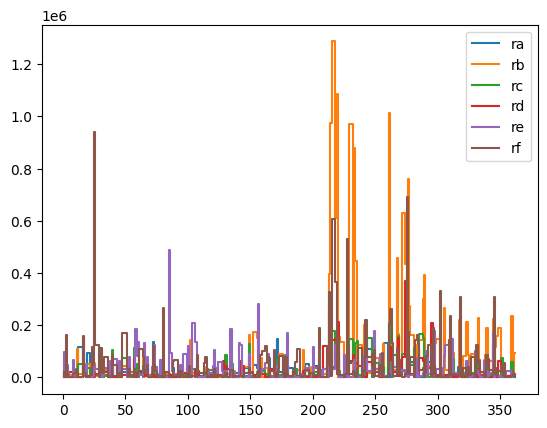

In [20]:
for v in returns:
    # print(f"=============={v}==============")
    plt.step(vols["day"], vols[v], label=v)
    # plt.plot(vols_bm[v])
plt.legend()
plt.show()

## Check autocorrelation

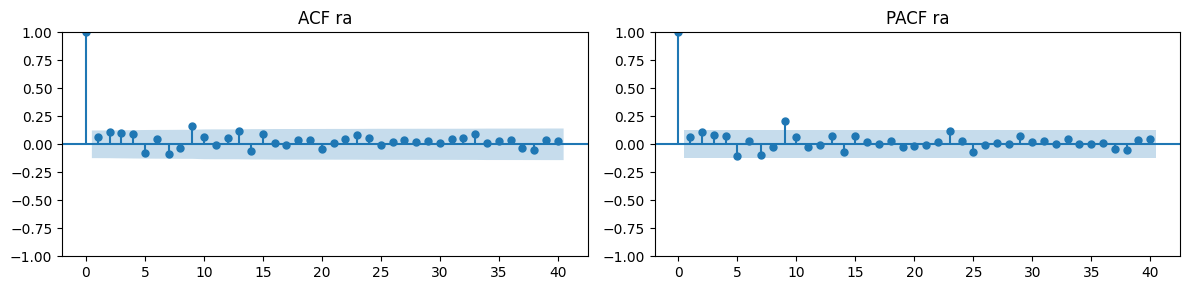

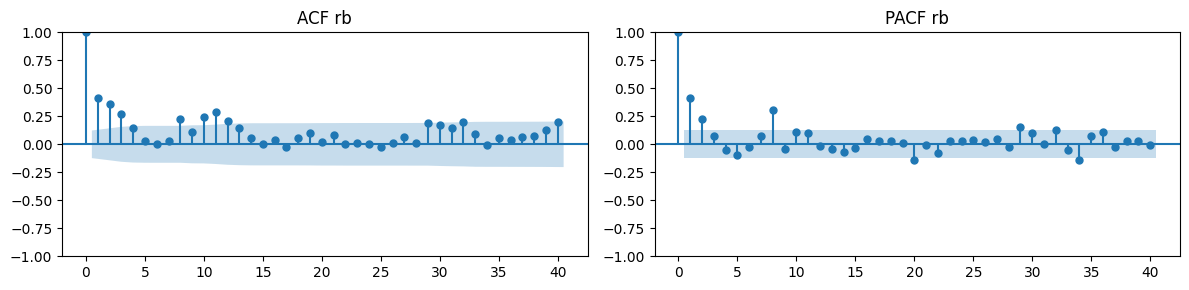

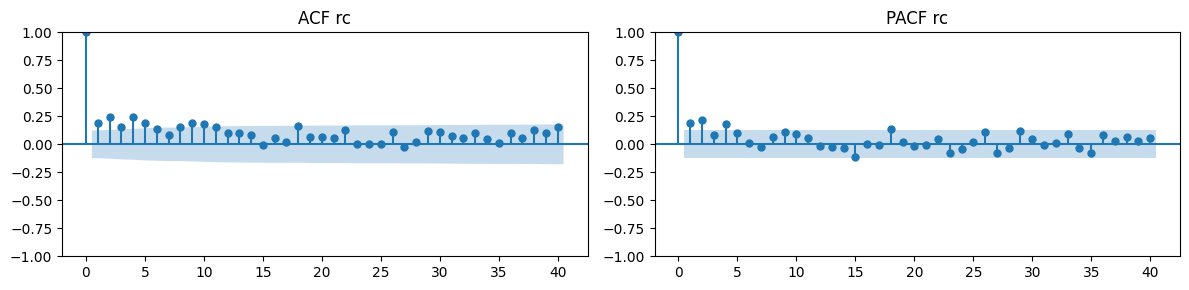

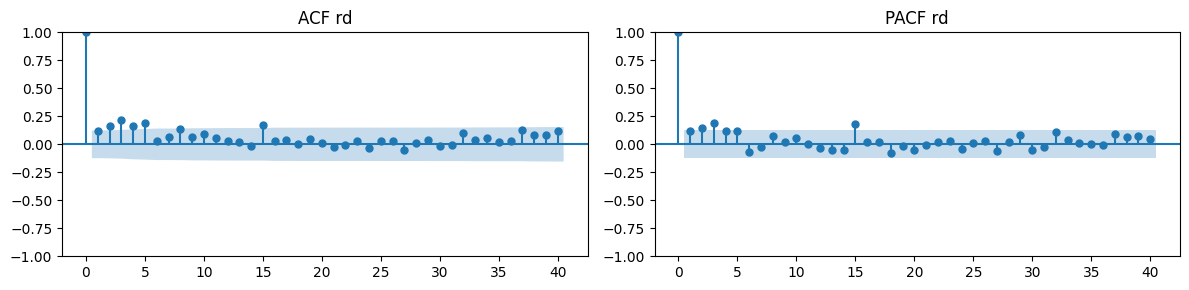

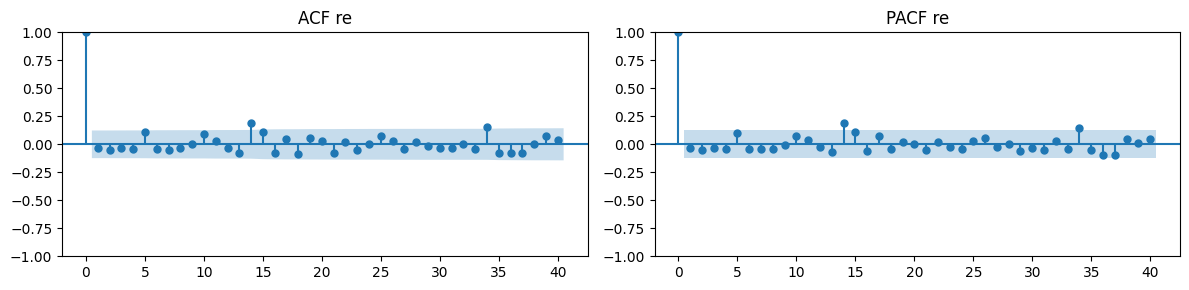

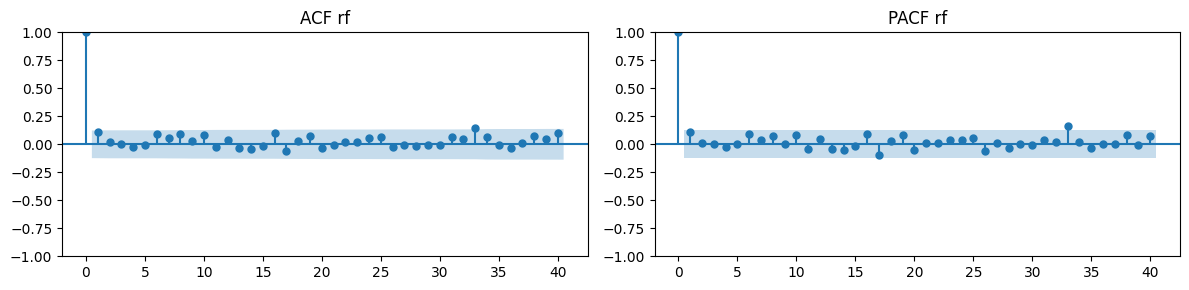

In [21]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acfs, pacfs = {}, {}
for r in returns:
    data = vols[r].drop_nulls().to_numpy()
    acfs[r] = acf(data, nlags=40, alpha=0.05)
    pacfs[r] = pacf(data, nlags=40, alpha=0.05)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(data, lags=40, alpha=0.05, ax=ax1)
    plot_pacf(data, lags=40, alpha=0.05, ax=ax2)
    ax1.set_title(f"ACF {r}")
    ax2.set_title(f"PACF {r}")
    plt.tight_layout()
    plt.show()

## Check daily volatilities

=====================ra=====================
17982.47878628152 27192.16102290039


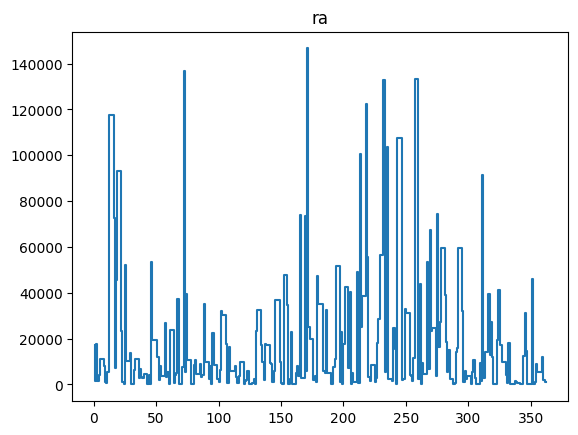

=====================rb=====================
82644.73349784173 182734.41305718443


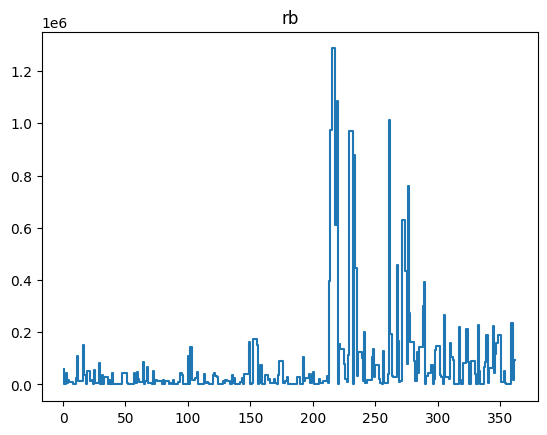

=====================rc=====================
29595.90624321227 44021.71977185721


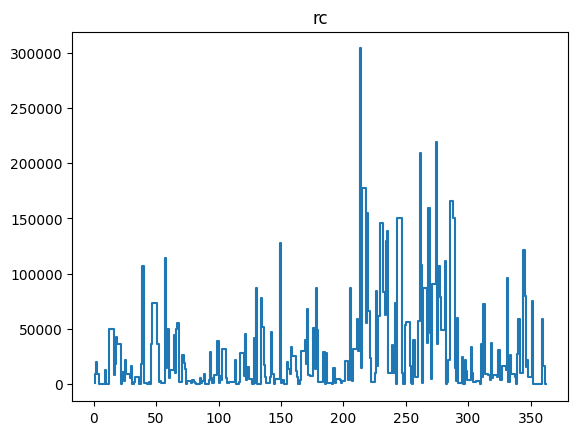

=====================rd=====================
21770.137741783383 41156.85897187098


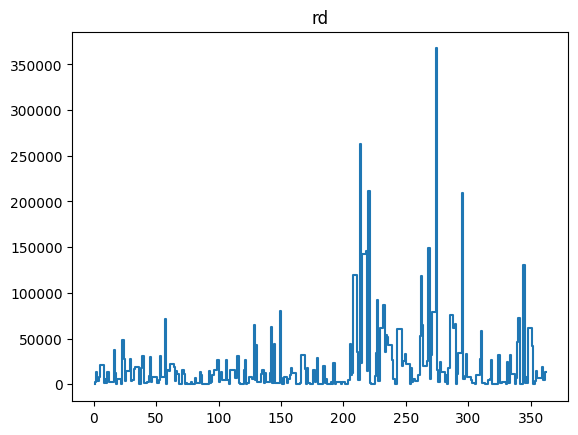

=====================re=====================
37028.07534749461 53494.28876560439


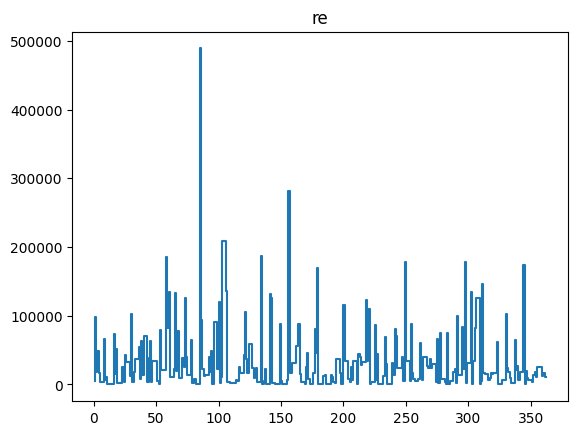

=====================rf=====================
53530.229017554586 106283.88990633385


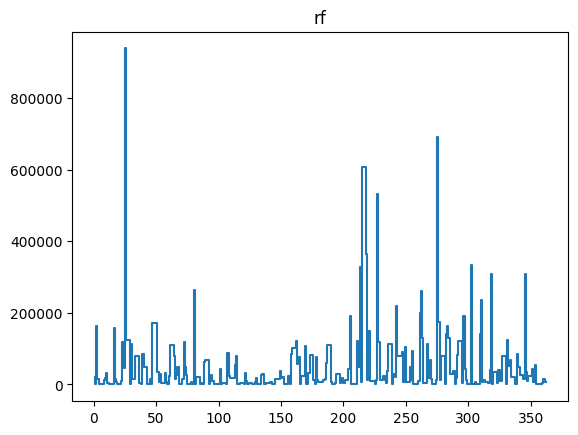

In [22]:
for r in returns:
    print(f"====================={r}=====================")
    print(vols[r].mean(), vols[r].std())
    plt.step(vols["day"], vols[r])
    plt.title(r)
    plt.show()

## Check the short day

In [23]:
print(vols.filter(pl.col("day") == 327))
print(vols.mean())

shape: (1, 7)
┌─────┬─────────────┬────────────┬─────────────┬─────────────┬──────────┬─────────────┐
│ day ┆ ra          ┆ rb         ┆ rc          ┆ rd          ┆ re       ┆ rf          │
│ --- ┆ ---         ┆ ---        ┆ ---         ┆ ---         ┆ ---      ┆ ---         │
│ i64 ┆ f64         ┆ f64        ┆ f64         ┆ f64         ┆ f64      ┆ f64         │
╞═════╪═════════════╪════════════╪═════════════╪═════════════╪══════════╪═════════════╡
│ 327 ┆ 17023.48491 ┆ 599.788468 ┆ 3996.709685 ┆ 1756.642481 ┆ 12.21471 ┆ 10380.70635 │
└─────┴─────────────┴────────────┴─────────────┴─────────────┴──────────┴─────────────┘
shape: (1, 7)
┌────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ day        ┆ ra           ┆ rb           ┆ rc          ┆ rd          ┆ re          ┆ rf          │
│ ---        ┆ ---          ┆ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ f64        ┆ f64          ┆ f64          ┆ f64     

In [24]:
np.sqrt(391 / 211)

np.float64(1.3612790194226823)

## Check lagged cross correlation

In [25]:
for lag in [1, 5, 10, 21, 42, 63]:
    lagged = (
        vols.select(returns).shift(lag).rename({c: f"{c}_lag{lag}" for c in returns})
    )
    combined = pl.concat([vols.select(returns), lagged], how="horizontal").drop_nulls()
    corr = combined.corr()
    n = len(returns)
    block = corr[:n, n:]
    block = block.rename({f"{c}_lag{lag}": c for c in returns})
    block = block.insert_column(0, pl.Series("name", returns))
    print(f"\ncorr(RV_i(t), RV_j(t-{lag})):")
    print(block)


corr(RV_i(t), RV_j(t-1)):
shape: (6, 7)
┌──────┬───────────┬──────────┬───────────┬───────────┬───────────┬───────────┐
│ name ┆ ra        ┆ rb       ┆ rc        ┆ rd        ┆ re        ┆ rf        │
│ ---  ┆ ---       ┆ ---      ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str  ┆ f64       ┆ f64      ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞══════╪═══════════╪══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ ra   ┆ 0.068088  ┆ 0.281452 ┆ 0.211275  ┆ 0.174652  ┆ -0.03328  ┆ 0.082428  │
│ rb   ┆ 0.272183  ┆ 0.411716 ┆ 0.313772  ┆ 0.276123  ┆ -0.024338 ┆ 0.270281  │
│ rc   ┆ 0.129298  ┆ 0.377867 ┆ 0.189135  ┆ 0.125046  ┆ 0.009211  ┆ 0.105176  │
│ rd   ┆ 0.076369  ┆ 0.488546 ┆ 0.23187   ┆ 0.116605  ┆ -0.041361 ┆ 0.057811  │
│ re   ┆ -0.001705 ┆ 0.062159 ┆ -0.001913 ┆ -0.034395 ┆ -0.03681  ┆ -0.016934 │
│ rf   ┆ -0.003398 ┆ 0.276743 ┆ 0.228965  ┆ 0.304963  ┆ -0.035012 ┆ 0.111318  │
└──────┴───────────┴──────────┴───────────┴───────────┴───────────┴───────────┘

## Model fitting/prediction

In [26]:
from collections.abc import Callable, Sequence


# ---- pooling: aggregate the daily-RV expr over a window of w trading days ----
# Daily RV is itself sqrt(daily variance); the choice is how those vols compose.
def pool_mean(e: pl.Expr, w: int) -> pl.Expr:
    """Plain average of daily RV over w days --- the literal Corsi HAR pooling."""
    return e.rolling_mean(w)


def pool_rms(e: pl.Expr, w: int) -> pl.Expr:
    """RMS of daily RV over w days: sqrt(mean RV^2). Dimensionally consistent
    (variances are additive, vols are not); stays on the daily-vol scale."""
    return e.pow(2).rolling_mean(w).sqrt()


# ---- feature builders: act on the daily-RV expr, return a causal (info<=t) expr ----
def ewma(half_life: float, on_variance: bool = False):
    """Exponentially weighted moving avg of daily RV, info up to row t (causal).

    A self-contained causal feature --- pass it in `feature_fns`.
    half_life : decay in trading days. RiskMetrics lambda=0.94 ~= half_life 11.
    on_variance : if True, EWMA the variance (RV^2) RiskMetrics-style and sqrt
                  back; if False, EWMA the vol series directly.
    """

    def fn(e: pl.Expr) -> pl.Expr:
        if on_variance:
            return e.pow(2).ewm_mean(half_life=half_life, adjust=False).sqrt()
        return e.ewm_mean(half_life=half_life, adjust=False)

    return fn


def make_features_targets(
    vols: pl.DataFrame,
    cols: Sequence[str],
    windows: Sequence[int] = (1, 5, 10, 21, 42, 63),
    horizon: int = 21,
    pool: Callable[[pl.Expr, int], pl.Expr] = pool_mean,
    # pool: Callable[[pl.Expr, int], pl.Expr] = pool_rms,
    feature_fns: dict[str, Callable[[pl.Expr], pl.Expr]] | None = None,
    target_fn: Callable[[pl.Expr], pl.Expr] | None = None,
    day_col: str = "day",
    drop_nulls: bool = False,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Turn a daily realized-vol frame into (features, target) frames.

    `vols` has one row per trading day plus `day_col`. Rows are assumed to be
    consecutive trading days, so a window / horizon of N rows == N trading days.
    All features use info up to and including day t; the target is strictly
    forward (t+1..t+h), so there is no overlap and no leakage. For row t:
      HAR feature {c}_avg{w} = pool of daily RV over the trailing w days [t-w+1..t]
      extra       {c}{name}  = feature_fns[name](col c)   (causal)
      target      {c}_fwd    = pool of daily RV over the forward h days [t+1..t+h]

    windows : HAR averaging windows in trading days. (1,5,21) are the classic
              daily / weekly / monthly HAR-RV components (Corsi 2009 uses 22).
              w=1 is RV(t) itself and keeps the bare name {c}.
    horizon : 21 is the usual "1 month" (252 trading days / 12 ~= 21); Corsi's
              HAR-RV uses 22; 20 is just a round "4 weeks". Default 21.
    pool    : (expr, w)->expr aggregator used for BOTH the HAR features and the
              default target, so the two always share one convention. pool_rms
              (default) is dimensionally consistent; pool_mean is literal Corsi.
    feature_fns : optional {name: fn(expr)->expr} extra causal features, e.g.
              {"_ewma11": ewma(11)}. Applied per column, info up to t.
    target_fn : optional override of the forward target. Default is
              pool(., horizon) shifted back h rows. Must be forward-looking.
    drop_nulls : if False (default) keep every row from day 1 --- partial
              windows (head) and missing forward targets (tail) stay null, so
              you can experiment with models that don't need a full HAR window.
              Set True for a ready-to-fit frame with the head/tail trimmed.

    Returns (X, y), both keyed by `day_col` and row-aligned.
    """
    vols = vols.sort(day_col)
    target_fn = target_fn or (lambda e: pool(e, horizon).shift(-horizon))

    feature_exprs = [
        pool(pl.col(c), w).alias(f"{c}" + (f"_avg{w}" if w != 1 else ""))
        for c in cols
        for w in windows
    ]
    if feature_fns:
        feature_exprs += [
            fn(pl.col(c)).alias(f"{c}{name}")
            for name, fn in feature_fns.items()
            for c in cols
        ]
    target_exprs = [target_fn(pl.col(c)).alias(f"{c}_fwd") for c in cols]

    combined = vols.select(pl.col(day_col), *feature_exprs, *target_exprs)
    if drop_nulls:
        combined = combined.drop_nulls()  # trims the window head + horizon tail

    feat_names = [e.meta.output_name() for e in feature_exprs]
    tgt_names = [e.meta.output_name() for e in target_exprs]
    return combined.select(day_col, *feat_names), combined.select(day_col, *tgt_names)

In [28]:
windows = [1, 5, 10, 21, 42, 63]
X, y = make_features_targets(
    vols,
    returns,
    # 5 trading days ~= one week; 10/15 are two-/three-week windows.
    windows=windows,
    horizon=21,
    # pool=pool_rms,  # pool_mean for the literal Corsi HAR average
    pool=pool_mean if USE_VAR else pool_rms,  # pool_mean for the literal Corsi HAR average
    feature_fns={
        f"_ewma{i}": ewma(i, on_variance=True) 
        if USE_VAR else
        ewma(i, on_variance=False) 
        for i in windows
    },
)
print("X:", X.shape, " y:", y.shape)
display(X.head())
display(y.head())

X: (252, 73)  y: (252, 7)


day,ra,ra_avg5,ra_avg10,ra_avg21,ra_avg42,ra_avg63,rb,rb_avg5,rb_avg10,rb_avg21,rb_avg42,rb_avg63,rc,rc_avg5,rc_avg10,rc_avg21,rc_avg42,rc_avg63,rd,rd_avg5,rd_avg10,rd_avg21,rd_avg42,rd_avg63,re,re_avg5,re_avg10,re_avg21,re_avg42,re_avg63,rf,rf_avg5,rf_avg10,rf_avg21,rf_avg42,rf_avg63,ra_ewma1,rb_ewma1,rc_ewma1,rd_ewma1,re_ewma1,rf_ewma1,ra_ewma5,rb_ewma5,rc_ewma5,rd_ewma5,re_ewma5,rf_ewma5,ra_ewma10,rb_ewma10,rc_ewma10,rd_ewma10,re_ewma10,rf_ewma10,ra_ewma21,rb_ewma21,rc_ewma21,rd_ewma21,re_ewma21,rf_ewma21,ra_ewma42,rb_ewma42,rc_ewma42,rd_ewma42,re_ewma42,rf_ewma42,ra_ewma63,rb_ewma63,rc_ewma63,rd_ewma63,re_ewma63,rf_ewma63
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,17030.598942,null,null,null,null,null,59281.456021,null,null,null,null,null,1416.534398,null,null,null,null,null,36.000002,null,null,null,null,null,4397.269118,null,null,null,null,null,21250.401991,null,null,null,null,null,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991
2,1358.047783,null,null,null,null,null,294.577309,null,null,null,null,null,9393.72113,null,null,null,null,null,2523.97008,null,null,null,null,null,98665.391974,null,null,null,null,null,33.4898,null,null,null,null,null,12080.678667,41918.837077,6717.461067,1784.897892,69836.221079,15026.322011,15897.621211,55311.655797,3629.007736,908.722266,35735.207187,19827.329802,16454.227692,57262.162743,2789.533701,654.077605,25883.49912,20526.537117,16753.628147,58311.157303,2192.368729,456.169146,18297.042046,20902.574846,16891.538481,58794.304957,1848.804207,324.878952,13355.160886,21075.770875,16937.76371,58956.242189,1717.603124,266.434255,11209.083124,21133.821208
3,17497.593386,null,null,null,null,null,43401.040018,null,null,null,null,null,20035.785602,null,null,null,null,null,13678.595957,null,null,null,null,null,18077.20056,null,null,null,null,null,162045.441037,null,null,null,null,null,15035.101784,42666.375382,14942.50628,9754.225952,51009.229335,115075.008829,16113.690658,53918.288282,7964.303156,4993.934888,33970.569734,61167.071288,16526.156823,56440.374554,5843.213323,3595.686605,25435.692151,46385.247533,16778.301528,57887.405225,4205.262029,2505.248025,18289.945689,35711.423864,16901.633372,58574.920918,3151.635656,1779.423909,13445.807911,29440.146075,16943.989473,58808.304846,2703.769441,1455.166059,11306.831681,27001.390195
4,1563.109228,null,null,null,null,null,6876.45371,null,null,null,null,null,9573.405934,null,null,null,null,null,3356.249211,null,null,null,null,null,49065.033487,null,null,null,null,null,14765.86832,null,null,null,null,null,10688.722939,30559.001979,12548.477898,7294.152887,50046.573251,82037.456458,15045.119895,50368.34184,8190.432517,4813.436154,36280.141559,57317.633299,15968.339375,54546.842137,6163.944433,3580.15251,27656.163199,44967.837821,16506.076383,56953.380252,4481.714968,2537.365512,20045.549168,35227.517055,16763.93198,58100.225002,3357.135907,1816.287155,14738.883583,29259.261395,16851.826906,58490.101843,2869.358329,1489.158802,12360.710584,26897.643215
5,4012.364213,8292.34271,null,null,null,null,15712.494273,25113.204266,null,null,null,null,387.800513,8161.449516,null,null,null,null,8483.807169,5615.724484,null,null,null,null,17244.506523,37489.880332,null,null,null,null,0.0,39619.04023,null,null,null,null,8073.037367,24297.480098,8877.350021,7911.373156,37430.151612,58009.241773,14111.62778,47334.124455,7643.217394,5430.19

day,ra_fwd,rb_fwd,rc_fwd,rd_fwd,re_fwd,rf_fwd
i64,f64,f64,f64,f64,f64,f64
1,23193.45372,30822.661627,13181.177416,12257.029065,30236.863064,84518.715446
2,23134.920792,32578.758962,12733.376831,12345.735118,25676.647992,85308.435268
3,22607.819057,30570.355997,11880.040238,12467.144445,25691.059039,78363.286261
4,23064.016272,31536.338798,11736.662067,13225.053143,25117.66526,81408.619163
5,23003.466838,30796.321417,11719.035676,12829.685831,26868.656471,81669.744549


### PCA diagnostic on the pre-modeling feature matrix

This checks the standardized HAR/EWMA feature matrix immediately after `X, y` are built, before adding the GARCH benchmark or any model-specific transforms.

component,explained_variance,explained_variance_ratio,cumulative_ratio
str,f64,f64,f64
"""PC1""",43.036787,0.594587,0.594587
"""PC2""",8.031103,0.110956,0.705543
"""PC3""",4.926901,0.068069,0.773612
"""PC4""",3.684316,0.050902,0.824514
"""PC5""",1.829648,0.025278,0.849792
"""PC6""",1.750301,0.024182,0.873974
"""PC7""",1.338025,0.018486,0.89246
"""PC8""",1.188671,0.016422,0.908882
"""PC9""",1.005142,0.013887,0.922769


feature,PC1,PC2,PC3,PC4,PC5,max_abs_loading
str,f64,f64,f64,f64,f64,f64
"""re_avg10""",-0.03595,-0.019472,0.36834,0.04493,0.006702,0.36834
"""re_ewma5""",-0.08064,-0.009325,0.361611,0.053358,0.043495,0.361611
"""re_avg5""",-0.017514,0.004853,0.350368,0.011129,0.030668,0.350368
"""rc""",0.063217,0.155854,-0.02819,-0.128507,0.347107,0.347107
"""re_ewma1""",-0.022041,0.013479,0.342332,-0.006877,0.113699,0.342332
…,…,…,…,…,…,…
"""ra_ewma5""",0.096557,0.178568,-0.019318,0.287203,0.059484,0.287203
"""ra_ewma10""",0.111554,0.123645,-0.014039,0.284142,0.053965,0.284142
"""rb_avg10""",0.12141,0.118556,0.050345,-0.051984,-0.280072,0.280072


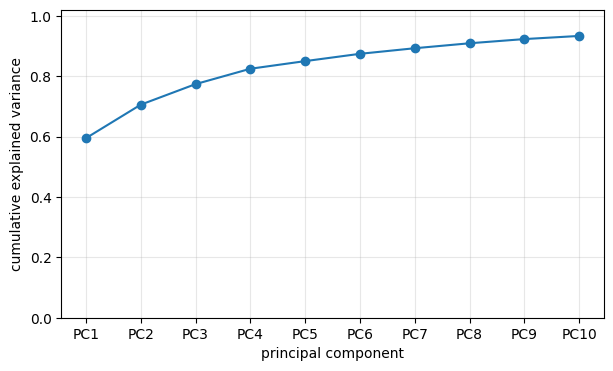

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# pca_feature_cols = [c for c in X.columns if c != "day"]
pca_feature_cols = [
    c
    for c in X.columns
    if c != "day"
    # and c.startswith("log_")
    # and (
    #     c.endswith("_ewma21")
    #     #  or c.endswith("_ewma11") or c.endswith("_ewma21")
    # )
]
# print(pca_feature_cols)
X_pca = X.select(["day", *pca_feature_cols]).drop_nulls().drop_nans()
# display(X_pca)
X_pca_scaled = StandardScaler().fit_transform(X_pca.select(pca_feature_cols).to_numpy())

pca = PCA()
pca_scores = pca.fit_transform(X_pca_scaled)
pca_summary = pl.DataFrame(
    {
        "component": [f"PC{i + 1}" for i in range(len(pca.explained_variance_ratio_))],
        "explained_variance": pca.explained_variance_,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_ratio": np.cumsum(pca.explained_variance_ratio_),
    }
)
display(pca_summary.head(10))

n_loading_components = min(5, len(pca_feature_cols))
loading_cols = [f"PC{i + 1}" for i in range(n_loading_components)]
pca_loadings = pl.DataFrame(
    {
        "feature": pca_feature_cols,
        **{f"PC{i + 1}": pca.components_[i] for i in range(n_loading_components)},
    }
)
display(
    pca_loadings.with_columns(
        pl.max_horizontal([pl.col(c).abs() for c in loading_cols]).alias(
            "max_abs_loading"
        )
    )
    .sort("max_abs_loading", descending=True)
    .head(15)
)

plt.figure(figsize=(7, 4))
plt.plot(
    pca_summary["component"][:10],
    pca_summary["cumulative_ratio"][:10],
    marker="o",
)
plt.ylim(0, 1.02)
plt.ylabel("cumulative explained variance")
plt.xlabel("principal component")
plt.grid(alpha=0.3)
plt.show()

In [30]:
for r in reversed(pca_loadings.sort("PC1").rows()):
    print(r[0], r[1])

rc_ewma21 0.14958989614699733
rb_ewma21 0.14853604325983655
rc_ewma10 0.14727326904902613
rd_ewma21 0.14574888535427477
rd_ewma10 0.1452686872288183
rb_ewma42 0.14415122916717307
rb_ewma10 0.14356208008447102
rf_ewma10 0.14352228466799496
rc_ewma42 0.14135524742940186
ra_ewma42 0.1406990193203535
rb_avg42 0.1404916264950723
rb_ewma63 0.1401802082569128
rf_avg21 0.13973013805323703
ra_avg63 0.13927459010095206
ra_ewma63 0.1392182530543188
rd_avg42 0.13861260463199637
rd_ewma42 0.13749742001797055
rf_avg42 0.13739357297556581
rc_avg42 0.1373918771524687
rf_ewma5 0.13709202466799317
rf_ewma21 0.13674912105998135
rc_ewma63 0.13579202378533672
rc_ewma5 0.1354068514366907
rb_avg21 0.13447808948369017
rb_avg63 0.13391562978221
rc_avg21 0.13334989330071098
rb_ewma5 0.1332270474414868
rd_avg21 0.1328533921608925
rd_ewma63 0.13255655973458766
ra_ewma21 0.1320545683579758
rc_avg63 0.13197400843251775
rd_ewma5 0.13190879909406092
rd_avg63 0.13131465353136393
ra_avg42 0.13100593262961113
rf_ewma42 

In [31]:
X.sort("day")

day,ra,ra_avg5,ra_avg10,ra_avg21,ra_avg42,ra_avg63,rb,rb_avg5,rb_avg10,rb_avg21,rb_avg42,rb_avg63,rc,rc_avg5,rc_avg10,rc_avg21,rc_avg42,rc_avg63,rd,rd_avg5,rd_avg10,rd_avg21,rd_avg42,rd_avg63,re,re_avg5,re_avg10,re_avg21,re_avg42,re_avg63,rf,rf_avg5,rf_avg10,rf_avg21,rf_avg42,rf_avg63,ra_ewma1,rb_ewma1,rc_ewma1,rd_ewma1,re_ewma1,rf_ewma1,ra_ewma5,rb_ewma5,rc_ewma5,rd_ewma5,re_ewma5,rf_ewma5,ra_ewma10,rb_ewma10,rc_ewma10,rd_ewma10,re_ewma10,rf_ewma10,ra_ewma21,rb_ewma21,rc_ewma21,rd_ewma21,re_ewma21,rf_ewma21,ra_ewma42,rb_ewma42,rc_ewma42,rd_ewma42,re_ewma42,rf_ewma42,ra_ewma63,rb_ewma63,rc_ewma63,rd_ewma63,re_ewma63,rf_ewma63
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,17030.598942,null,null,null,null,null,59281.456021,null,null,null,null,null,1416.534398,null,null,null,null,null,36.000002,null,null,null,null,null,4397.269118,null,null,null,null,null,21250.401991,null,null,null,null,null,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991,17030.598942,59281.456021,1416.534398,36.000002,4397.269118,21250.401991
2,1358.047783,null,null,null,null,null,294.577309,null,null,null,null,null,9393.72113,null,null,null,null,null,2523.97008,null,null,null,null,null,98665.391974,null,null,null,null,null,33.4898,null,null,null,null,null,12080.678667,41918.837077,6717.461067,1784.897892,69836.221079,15026.322011,15897.621211,55311.655797,3629.007736,908.722266,35735.207187,19827.329802,16454.227692,57262.162743,2789.533701,654.077605,25883.49912,20526.537117,16753.628147,58311.157303,2192.368729,456.169146,18297.042046,20902.574846,16891.538481,58794.304957,1848.804207,324.878952,13355.160886,21075.770875,16937.76371,58956.242189,1717.603124,266.434255,11209.083124,21133.821208
3,17497.593386,null,null,null,null,null,43401.040018,null,null,null,null,null,20035.785602,null,null,null,null,null,13678.595957,null,null,null,null,null,18077.20056,null,null,null,null,null,162045.441037,null,null,null,null,null,15035.101784,42666.375382,14942.50628,9754.225952,51009.229335,115075.008829,16113.690658,53918.288282,7964.303156,4993.934888,33970.569734,61167.071288,16526.156823,56440.374554,5843.213323,3595.686605,25435.692151,46385.247533,16778.301528,57887.405225,4205.262029,2505.248025,18289.945689,35711.423864,16901.633372,58574.920918,3151.635656,1779.423909,13445.807911,29440.146075,16943.989473,58808.304846,2703.769441,1455.166059,11306.831681,27001.390195
4,1563.109228,null,null,null,null,null,6876.45371,null,null,null,null,null,9573.405934,null,null,null,null,null,3356.249211,null,null,null,null,null,49065.033487,null,null,null,null,null,14765.86832,null,null,null,null,null,10688.722939,30559.001979,12548.477898,7294.152887,50046.573251,82037.456458,15045.119895,50368.34184,8190.432517,4813.436154,36280.141559,57317.633299,15968.339375,54546.842137,6163.944433,3580.15251,27656.163199,44967.837821,16506.076383,56953.380252,4481.714968,2537.365512,20045.549168,35227.517055,16763.93198,58100.225002,3357.135907,1816.287155,14738.883583,29259.261395,16851.826906,58490.101843,2869.358329,1489.158802,12360.710584,26897.643215
5,4012.364213,8292.34271,null,null,null,null,15712.494273,25113.204266,null,null,null,null,387.800513,8161.449516,null,null,null,null,8483.807169,5615.724484,null,null,null,null,17244.506523,37489.880332,null,null,null,null,0.0,39619.04023,null,null,null,null,8073.037367,24297.480098,8877.350021,7911.373156,37430.151612,58009.241773,14111.62778,47334.124455,7643.217394,5430.19

### GARCH benchmark

In [32]:
from arch import arch_model


def fit_garch(returns, p=1, q=1):
    model = arch_model(returns, vol="Garch", p=p, q=q, rescale=True)
    res = model.fit(disp="off")
    print(res.summary())
    return res


def garch_predict(res):
    forecast = res.forecast(horizon=21, reindex=False)
    # Sum daily variances over 21 days for monthly variance
    monthly_var = forecast.variance.iloc[-1].sum()
    return np.sqrt(monthly_var)
    # monthly_vol_ann = np.sqrt(monthly_var * 252 / 21) / 100  # if rescaled to pct
    # print(f"Annualized vol: {monthly_vol_ann:.2%}")

In [33]:
def garch_features(ret_cc, stocks, horizon=21, day_col="day", min_obs=63):
    """Causal expanding-window GARCH(1,1) features from close-to-close returns.

    For each day t, fit only on close-to-close returns observed through t and
    forecast the average daily volatility over t+1..t+horizon. This makes the
    GARCH benchmark comparable to the causal HAR/EWMA features in CV.
    """
    ret_cc = ret_cc.sort(day_col)
    out = {day_col: ret_cc[day_col]}
    for s in stocks:
        col = f"r{s}"
        r = ret_cc[col].to_numpy()
        filtered = np.full(len(r), np.nan)
        fwd = np.full(len(r), np.nan)
        for i in range(len(r)):
            hist = r[: i + 1]
            hist = hist[np.isfinite(hist)]
            if len(hist) < min_obs:
                continue
            res = arch_model(hist, vol="Garch", p=1, q=1, rescale=True).fit(
                disp="off", show_warning=False
            )
            sc = res.scale  # arch may rescale returns internally; undo it
            fc = res.forecast(horizon=horizon, reindex=False)
            filtered[i] = np.asarray(res.conditional_volatility)[-1] / sc
            fwd[i] = np.sqrt(fc.variance.to_numpy()[-1].mean()) / sc
        out[f"r{s}_garch"] = filtered
        out[f"r{s}_garch_fwd"] = fwd
    return pl.DataFrame(out).with_columns(pl.exclude(day_col).fill_nan(None))

In [34]:
garch = garch_features(ret_cc, stocks, horizon=21)
display(garch.head())

# join GARCH columns onto X (drop stale columns so re-running stays idempotent)
garch_cols = [c for c in X.columns if c.endswith("_garch") or c.endswith("_garch_fwd")]
if garch_cols:
    X = X.drop(garch_cols)
X = X.join(garch, on="day", how="left")
print("X with GARCH:", X.shape)

day,ra_garch,ra_garch_fwd,rb_garch,rb_garch_fwd,rc_garch,rc_garch_fwd,rd_garch,rd_garch_fwd,re_garch,re_garch_fwd,rf_garch,rf_garch_fwd
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,null,null,null,null,null,null,null,null,null,null,null,null
2,null,null,null,null,null,null,null,null,null,null,null,null
3,null,null,null,null,null,null,null,null,null,null,null,null
4,null,null,null,null,null,null,null,null,null,null,null,null
5,null,null,null,null,null,null,null,null,null,null,null,null


X with GARCH: (252, 85)


### check rolling monthly vol

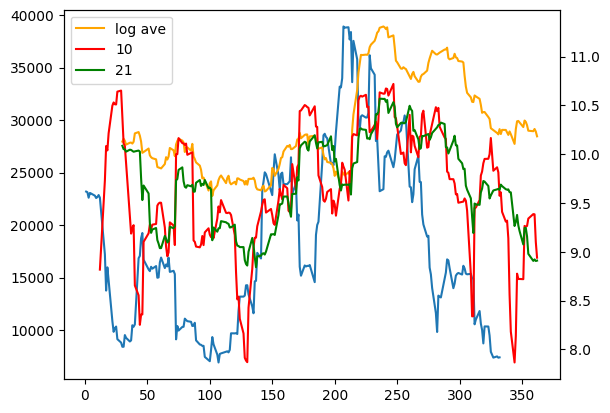

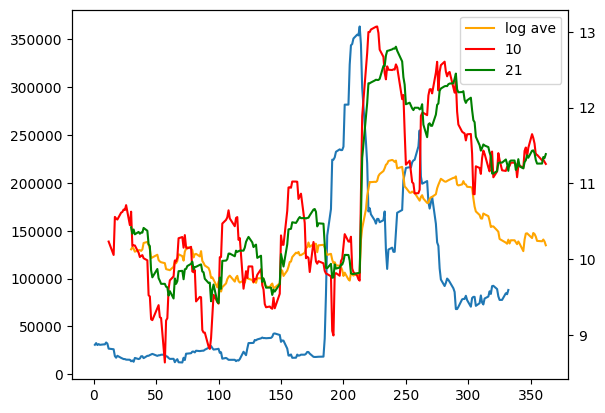

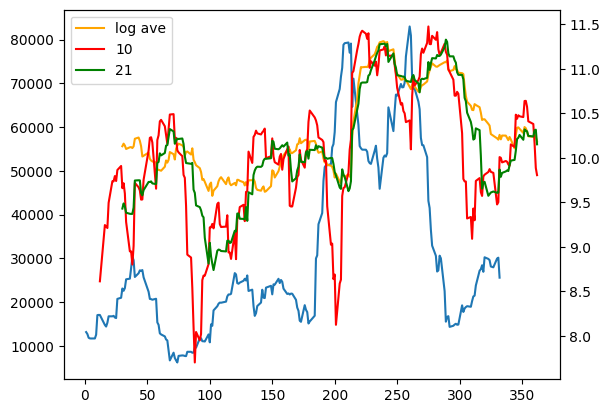

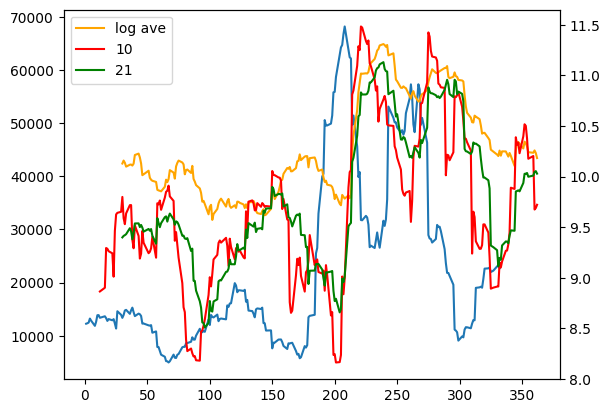

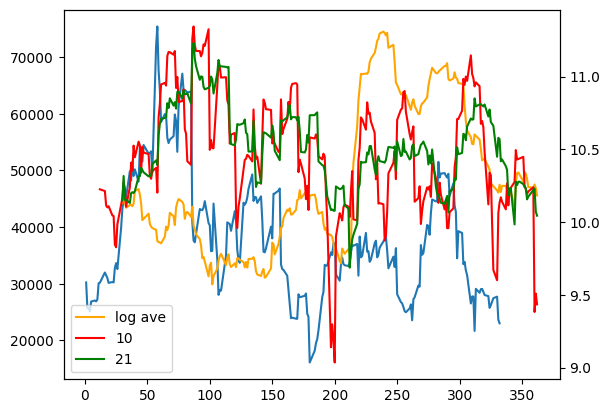

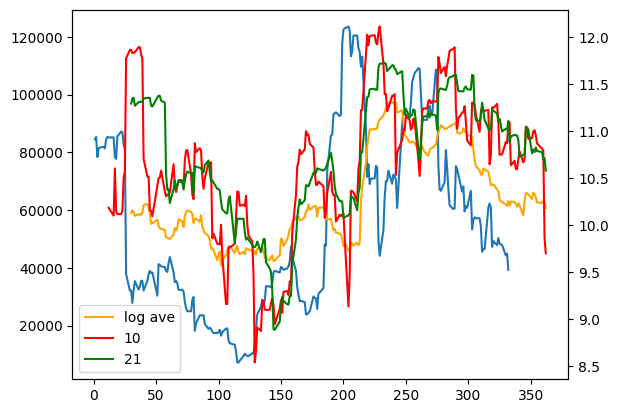

In [35]:
# for c in X.columns:
#     if c == "day":
#         continue
#     c1 = c.split("_")[0] + "_fwd"
#     print(f"=============={c}, {c1}===============")
#     plt.scatter(X[c], y[c1])
#     print(np.corrcoef(X[c], y[c1])[0, 1])
#     plt.show()

plot_log_sources = [
    f"{r}_avg{w}" for r in returns for w in [10, 21] if f"{r}_avg{w}" in X.columns
]
missing_plot_log_sources = [c for c in plot_log_sources if f"log_{c}" not in X.columns]
if missing_plot_log_sources:
    X = X.with_columns(
        [
            pl.when(pl.col(c) > 0)
            .then(pl.col(c).log())
            .otherwise(None)
            .alias(f"log_{c}")
            for c in missing_plot_log_sources
        ]
    )

vol_log_avg = sum([X[f"log_{r}_avg21"] / len(returns) for r in returns])
for r in returns:
    plt.plot(y["day"], y[f"{r}_fwd"])
    plt.twinx()
    plt.plot(X["day"], vol_log_avg, label="log ave", color="orange")
    # plt.plot(X["day"], X[f"log_{r}_avg5"], label="5", color="red")
    plt.plot(X["day"], X[f"log_{r}_avg10"], label="10", color="red")
    plt.plot(X["day"], X[f"log_{r}_avg21"], label="21", color="green")
    plt.legend()
    plt.show()

In [40]:
import itertools
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import LinearRegression


class PurgedWalkForwardCV:
    """Walk-forward CV for forward-looking targets.

    Train always precedes test; between them the last `purge` train rows are
    dropped --- their target window (horizon trading days) reaches into the
    test block, so keeping them would train the model on test-period outcomes.
    Because train is always before test there is no post-test embargo to do:
    purging the train tail removes the only leak path. Rows must be sorted by
    day, one consecutive trading day each.

    n_splits   : number of sequential test folds.
    purge      : rows dropped from the train tail; set to the target horizon.
    min_train  : rows before the first test fold.
    train_span : None -> expanding train window; int -> rolling window size.
    """

    def __init__(self, n_splits=5, purge=21, min_train=63, train_span=None):
        self.n_splits = n_splits
        self.purge = purge
        self.min_train = min_train
        self.train_span = train_span

    def split(self, X, y=None, groups=None):
        n = len(X)
        fold = (n - self.min_train) // self.n_splits
        if fold <= 0:
            raise ValueError("not enough rows for given n_splits / min_train")
        for k in range(self.n_splits):
            test_start = self.min_train + k * fold
            test_end = n if k == self.n_splits - 1 else test_start + fold
            train_end = test_start - self.purge
            if train_end <= 0:
                continue
            lo = 0 if self.train_span is None else max(0, train_end - self.train_span)
            yield np.arange(lo, train_end), np.arange(test_start, test_end)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


class PassthroughRegressor(BaseEstimator, RegressorMixin):
    """Dummy model: returns one feature column verbatim as the prediction.

    No fitting --- use it to score a precomputed forecast inside the same CV
    pipeline as the trainable models. To benchmark GARCH, call evaluate_model
    with features=["r{s}_garch_fwd"] and model=PassthroughRegressor().

    col : index of the feature column to pass through (0 = first feature).
    """

    def __init__(self, col=0):
        self.col = col

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return np.asarray(X)[:, self.col]


# class LogLogLinearRegressor(BaseEstimator, RegressorMixin):
#     """Linear regression in log(feature) / log(target), predicted on original scale."""

#     def __init__(self, fit_intercept=True, eps=1e-12):
#         self.fit_intercept = fit_intercept
#         self.eps = eps

#     def _log_positive(self, values):
#         values = np.asarray(values, dtype=float)
#         return np.log(np.maximum(values, self.eps))

#     def fit(self, X, y):
#         self.model_ = LinearRegression(fit_intercept=self.fit_intercept)
#         self.model_.fit(self._log_positive(X), self._log_positive(y).ravel())
#         self.coef_ = self.model_.coef_
#         self.intercept_ = self.model_.intercept_
#         return self

#     def predict(self, X):
#         return np.exp(self.model_.predict(self._log_positive(X)))


class ForwardStagewiseRegressor(BaseEstimator, RegressorMixin):
    """Forward stagewise residual regression with fixed coefficients.

    Features are normalized on each fit. At each step, regress the current
    residual on every remaining normalized feature individually, select the
    largest positive slope, fix that slope, and update the residual. Stop when
    the best remaining slope is at or below min_coef.
    """

    def __init__(self, max_features=3, min_coef=0.0, feature_names=None):
        self.max_features = max_features
        self.min_coef = min_coef
        self.feature_names = feature_names

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        n_features = X.shape[1]
        names = (
            list(self.feature_names)
            if self.feature_names is not None
            else [f"x{i}" for i in range(n_features)]
        )

        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.scale_ = np.where(self.scale_ == 0, 1.0, self.scale_)
        Xn = (X - self.mean_) / self.scale_

        selected = []
        remaining = list(range(n_features))
        intercept_norm = float(y.mean())
        residual = y - intercept_norm
        coef_norm = np.zeros(n_features)
        self.selection_path_ = []
        max_features = (
            n_features
            if self.max_features is None
            else min(self.max_features, n_features)
        )

        for step in range(1, max_features + 1):
            if not remaining:
                break

            X_remaining = Xn[:, remaining]
            denom = np.sum(X_remaining**2, axis=0)
            slopes = np.full(len(remaining), -np.inf)
            valid = denom > 0
            slopes[valid] = (X_remaining[:, valid].T @ residual) / denom[valid]

            best_pos = int(np.argmax(np.abs(slopes)))
            best_slope = float(slopes[best_pos])
            if np.abs(best_slope) <= self.min_coef:
                break

            feature_idx = remaining.pop(best_pos)
            selected.append(feature_idx)
            coef_norm[feature_idx] = best_slope
            residual = residual - best_slope * Xn[:, feature_idx]
            self.selection_path_.append(
                {
                    "step": step,
                    "feature": names[feature_idx],
                    "coef_norm": best_slope,
                }
            )

        coef = coef_norm / self.scale_
        intercept = float(intercept_norm - np.dot(coef_norm, self.mean_ / self.scale_))

        self.coef_ = coef
        self.intercept_ = intercept
        self.coef_norm_ = coef_norm
        self.selected_idx_ = np.array(selected, dtype=int)
        self.selected_feature_names_ = [names[i] for i in selected]
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))


def qlike(y_true, y_pred, eps=1e-6, on_variance=USE_VAR):
    """QLIKE on variance forecasts; negative vol forecasts get near-zero variance."""
    true_vol = np.asarray(y_true, dtype=float)
    pred_vol = np.asarray(y_pred, dtype=float)
    if on_variance:
        true_var = true_vol + eps
        pred_var = pred_vol + eps
    else:
        true_var = np.maximum(true_vol, 0.0) ** 2 + eps
        pred_var = np.maximum(pred_vol, 0.0) ** 2 + eps
    ratio = true_var / pred_var
    return float(np.mean(ratio - np.log(ratio) - 1.0))


DEFAULT_LOSS_FNS = {"rmse": rmse, "mse": mse, "qlike": qlike}


def _normalize_loss_fns(loss_fns=None, scorer=None):
    if loss_fns is None:
        loss_fns = scorer if scorer is not None else DEFAULT_LOSS_FNS
    if isinstance(loss_fns, dict):
        return dict(loss_fns)
    if callable(loss_fns):
        name = getattr(loss_fns, "__name__", "loss")
        return {name: loss_fns}
    normalized = {}
    for i, fn in enumerate(loss_fns):
        base_name = getattr(fn, "__name__", f"loss_{i + 1}")
        name = base_name if base_name not in normalized else f"{base_name}_{i + 1}"
        normalized[name] = fn
    return normalized


def evaluate_model(
    X,
    y,
    model,
    features,
    target,
    param_grid=None,
    cv=None,
    horizon=21,
    day_col="day",
    loss_fns=None,
    primary_loss="rmse",
    scorer=None,
):
    """Purged walk-forward CV for one (features -> target) model.

    X, y    : day-keyed frames (make_features_targets output, + GARCH join);
              joined on `day_col`, sorted, null rows dropped.
    model   : an unfitted sklearn-style estimator (must be clone-able).
    features: feature column names in X the model is given.
    target  : target column name in y.
    param_grid : optional {param: [values]}; every combination is scored and
              the one with the lowest mean fold error wins.
    cv      : splitter; default PurgedWalkForwardCV(purge=horizon).
    loss_fns: dict/list/callable of (y_true, y_pred) -> loss; default
              {rmse, mse, qlike}. A single legacy `scorer` is still accepted.
    primary_loss : loss name used for model/parameter selection.

    Returns dict for the BEST param combo with:
      best_params, best_model (refit on all rows),
      <loss>_mean/std, train_<loss>_mean/std --- validation/training stats,
      cv_mean, train_cv_mean, fold_errors    --- aliases for primary_loss,
      r2, pred_mean, pred_std,               --- prediction stats (r2 = pooled OOF),
      train_r2, train_r2_std,                --- mean per-fold in-sample R^2,
      true_mean, true_std,                   --- target stats (pooled OOF),
      results (one row per param combo, sorted by error; also includes the
               per-combo r2 / pred / true stats).
    """
    loss_fns = _normalize_loss_fns(loss_fns, scorer=scorer)
    if primary_loss not in loss_fns:
        primary_loss = next(iter(loss_fns))
    primary_mean_col = f"{primary_loss}_mean"
    primary_std_col = f"{primary_loss}_std"
    cv = cv or PurgedWalkForwardCV(purge=horizon)
    d = (
        X.select([day_col, *features])
        .join(y.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    Xa, ya = d.select(features).to_numpy(), d.select(target).to_numpy().ravel()

    grid = param_grid or {}
    combos = [dict(zip(grid, v)) for v in itertools.product(*grid.values())]

    rows = []
    for params in combos:
        errs = {name: [] for name in loss_fns}
        train_errs = {name: [] for name in loss_fns}
        preds, trues = [], []
        train_r2_folds = []  # per-fold in-sample R^2
        for tr, te in cv.split(Xa):
            m = clone(model).set_params(**params)
            m.fit(Xa[tr], ya[tr])
            train_p = m.predict(Xa[tr])
            p = m.predict(Xa[te])
            for loss_name, loss_fn in loss_fns.items():
                train_errs[loss_name].append(loss_fn(ya[tr], train_p))
                errs[loss_name].append(loss_fn(ya[te], p))
            preds.append(p)
            trues.append(ya[te])
            ya_tr = ya[tr]
            ss_res_tr = float(np.sum((ya_tr - train_p) ** 2))
            ss_tot_tr = float(np.sum((ya_tr - ya_tr.mean()) ** 2))
            train_r2_folds.append(
                1.0 - ss_res_tr / ss_tot_tr if ss_tot_tr > 0 else float("nan")
            )
        errs = {name: np.asarray(values, dtype=float) for name, values in errs.items()}
        train_errs = {
            name: np.asarray(values, dtype=float) for name, values in train_errs.items()
        }
        preds = np.concatenate(preds)  # pooled out-of-fold predictions
        trues = np.concatenate(trues)
        ss_res = float(np.sum((trues - preds) ** 2))
        ss_tot = float(np.sum((trues - trues.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        train_r2_arr = np.asarray(train_r2_folds, dtype=float)
        train_r2 = (
            float(np.nanmean(train_r2_arr)) if train_r2_arr.size else float("nan")
        )
        train_r2_std = (
            float(np.nanstd(train_r2_arr)) if train_r2_arr.size else float("nan")
        )
        metric_stats = {}
        for loss_name in loss_fns:
            metric_stats[f"{loss_name}_mean"] = float(errs[loss_name].mean())
            metric_stats[f"{loss_name}_std"] = float(errs[loss_name].std())
            metric_stats[f"train_{loss_name}_mean"] = float(
                train_errs[loss_name].mean()
            )
            metric_stats[f"train_{loss_name}_std"] = float(train_errs[loss_name].std())
        rows.append(
            {
                **params,
                **metric_stats,
                "cv_mean": metric_stats[primary_mean_col],
                "cv_std": metric_stats[primary_std_col],
                "train_cv_mean": metric_stats[f"train_{primary_mean_col}"],
                "train_cv_std": metric_stats[f"train_{primary_std_col}"],
                "r2": r2,
                "train_r2": train_r2,
                "train_r2_std": train_r2_std,
                "pred_mean": float(preds.mean()),
                "pred_std": float(preds.std()),
                "true_mean": float(trues.mean()),
                "true_std": float(trues.std()),
                "_params": params,
                "_errs": errs,
                "_train_errs": train_errs,
            }
        )

    rows.sort(key=lambda r: r[primary_mean_col])
    best = rows[0]
    best_model = clone(model).set_params(**best["_params"]).fit(Xa, ya)
    results = pl.DataFrame(
        [{k: v for k, v in r.items() if not k.startswith("_")} for r in rows]
    )
    out = {
        "best_params": best["_params"],
        "best_model": best_model,
        "losses": list(loss_fns),
        "primary_loss": primary_loss,
        "cv_mean": best[primary_mean_col],
        "cv_std": best[primary_std_col],
        "train_cv_mean": best[f"train_{primary_mean_col}"],
        "train_cv_std": best[f"train_{primary_std_col}"],
        "r2": best["r2"],
        "train_r2": best["train_r2"],
        "train_r2_std": best["train_r2_std"],
        "pred_mean": best["pred_mean"],
        "pred_std": best["pred_std"],
        "true_mean": best["true_mean"],
        "true_std": best["true_std"],
        "fold_errors": best["_errs"][primary_loss],
        "train_fold_errors": best["_train_errs"][primary_loss],
        "results": results,
    }
    for loss_name in loss_fns:
        out[f"{loss_name}_mean"] = best[f"{loss_name}_mean"]
        out[f"{loss_name}_std"] = best[f"{loss_name}_std"]
        out[f"train_{loss_name}_mean"] = best[f"train_{loss_name}_mean"]
        out[f"train_{loss_name}_std"] = best[f"train_{loss_name}_std"]
        out[f"{loss_name}_fold_errors"] = best["_errs"][loss_name]
        out[f"train_{loss_name}_fold_errors"] = best["_train_errs"][loss_name]
    return out


def _r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")


def _fit_score_test_phase(
    joined,
    model,
    features,
    target,
    params,
    test_start_day,
    test_end_day=None,
    purge=21,
    train_span=None,
    day_col="day",
    loss_fns=None,
):
    loss_fns = _normalize_loss_fns(loss_fns)
    days = joined[day_col].to_numpy()
    test_mask = days >= test_start_day
    if test_end_day is not None:
        test_mask &= days <= test_end_day
    test_idx = np.flatnonzero(test_mask)
    if len(test_idx) == 0:
        raise ValueError("test phase has no rows after feature/target alignment")

    train_end = int(test_idx[0]) - int(purge)
    if train_end <= 0:
        raise ValueError("not enough purged pre-test rows to fit final model")
    train_start = 0 if train_span is None else max(0, train_end - int(train_span))
    train_idx = np.arange(train_start, train_end)
    if len(train_idx) == 0:
        raise ValueError("final train phase is empty")

    Xa = joined.select(features).to_numpy()
    ya = joined.select(target).to_numpy().ravel()
    final_model = clone(model).set_params(**(params or {}))
    final_model.fit(Xa[train_idx], ya[train_idx])
    train_pred = final_model.predict(Xa[train_idx])
    test_pred = final_model.predict(Xa[test_idx])

    test_metrics = {name: fn(ya[test_idx], test_pred) for name, fn in loss_fns.items()}
    final_train_metrics = {
        name: fn(ya[train_idx], train_pred) for name, fn in loss_fns.items()
    }
    return {
        "report_model": final_model,
        "test_days": days[test_idx],
        "test_true": ya[test_idx],
        "test_pred": test_pred,
        "final_train_days": days[train_idx],
        "final_train_true": ya[train_idx],
        "final_train_pred": train_pred,
        "test_metrics": test_metrics,
        "final_train_metrics": final_train_metrics,
        "test_r2": _r2_score(ya[test_idx], test_pred),
        "final_train_r2": _r2_score(ya[train_idx], train_pred),
        "test_pred_mean": float(np.mean(test_pred)),
        "test_pred_std": float(np.std(test_pred)),
        "test_true_mean": float(np.mean(ya[test_idx])),
        "test_true_std": float(np.std(ya[test_idx])),
        "test_period": f"{days[test_idx[0]]}-{days[test_idx[-1]]}",
        "final_train_period": f"{days[train_idx[0]]}-{days[train_idx[-1]]}",
    }


def evaluate_model_with_test(
    X,
    y,
    model,
    features,
    target,
    param_grid=None,
    cv=None,
    horizon=21,
    day_col="day",
    loss_fns=None,
    primary_loss="qlike",
    test_start_day=None,
    test_end_day=None,
    purge=21,
    train_span=None,
):
    if test_start_day is None:
        return evaluate_model(
            X,
            y,
            model,
            features,
            target,
            param_grid=param_grid,
            cv=cv,
            horizon=horizon,
            day_col=day_col,
            loss_fns=loss_fns,
            primary_loss=primary_loss,
        )

    joined = (
        X.select([day_col, *features])
        .join(y.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    days = joined[day_col].to_numpy()
    test_mask = days >= test_start_day
    if test_end_day is not None:
        test_mask &= days <= test_end_day
    test_idx = np.flatnonzero(test_mask)
    if len(test_idx) == 0:
        raise ValueError("test phase has no rows after feature/target alignment")
    # CV phase ends right at the test boundary: no purge needed between the
    # last CV val fold and the test phase. Within each fold the train tail is
    # already purged (PurgedWalkForwardCV) so train -> val cannot leak; and
    # the final training step in _fit_score_test_phase still purges its own
    # tail so train -> test cannot leak either.
    cv_end = int(test_idx[0])
    if cv_end <= 0:
        raise ValueError("not enough pre-test rows for CV")

    cv_frame = joined.head(cv_end)
    cv_result = evaluate_model(
        cv_frame.select([day_col, *features]),
        cv_frame.select([day_col, target]),
        model,
        features,
        target,
        param_grid=param_grid,
        cv=cv,
        horizon=horizon,
        day_col=day_col,
        loss_fns=loss_fns,
        primary_loss=primary_loss,
    )
    test_result = _fit_score_test_phase(
        joined,
        model,
        features,
        target,
        params=cv_result["best_params"],
        test_start_day=test_start_day,
        test_end_day=test_end_day,
        purge=purge,
        train_span=train_span,
        day_col=day_col,
        loss_fns=loss_fns,
    )
    cv_result.update(test_result)
    for loss_name, value in test_result["test_metrics"].items():
        cv_result[f"test_{loss_name}"] = value
    for loss_name, value in test_result["final_train_metrics"].items():
        cv_result[f"final_train_{loss_name}"] = value
    return cv_result

### single feature checking

In [41]:
# # Market-level features: cross-stock arithmetic mean of log trailing RV features.
# # mkt_logavg{w} = mean_x[log(avg RV_x over trailing w trading days)].
# # w=1 collapses to log spot RV. These represent a "market" vol level and
# # are added only to the single-feature correlation comparison below, not to
# # the modelling specs in the next cell.
# MKT_WINDOWS = [1, 5, 10, 21, 42, 63]
# MKT_FEATURES = [f"mkt_logavg{w}" for w in MKT_WINDOWS]


# def _build_market_log_avg_features(vols_frame, stock_cols, windows, day_col="day"):
#     sorted_vols = vols_frame.sort(day_col)
#     exprs = []
#     for w in windows:
#         per_stock = []
#         for c in stock_cols:
#             source_col = f"{c}_avg{w}" if w > 1 else c
#             log_col = f"log_{source_col}"
#             if log_col in sorted_vols.columns:
#                 per_stock.append(pl.col(log_col))
#             else:
#                 per_stock.append(
#                     pl.when(pl.col(source_col) > 0)
#                     .then(pl.col(source_col).log())
#                     .otherwise(None)
#                 )
#         exprs.append(pl.mean_horizontal(per_stock).alias(f"mkt_logavg{w}"))
#     return sorted_vols.select(day_col, *exprs)


# _mkt_features_df = _build_market_log_avg_features(X, returns, MKT_WINDOWS)
# # Idempotent: drop existing mkt columns from X before re-joining.
# _existing_mkt = [c for c in MKT_FEATURES if c in X.columns]
# if _existing_mkt:
#     X = X.drop(_existing_mkt)
# X = X.join(_mkt_features_df, on="day", how="left")


# def market_level_candidates():
#     return [(f"MKT log-avg{w}", f"mkt_logavg{w}") for w in MKT_WINDOWS]


# def one_feature_candidates_for_stock(s, include_garch=True):
#     candidates = [
#         ("RV", s),
#         ("avg5", f"{s}_avg5"),
#         ("avg10", f"{s}_avg10"),
#         ("avg21", f"{s}_avg21"),
#         ("avg42", f"{s}_avg42"),
#         ("avg63", f"{s}_avg63"),
#         ("EWMA-1", f"{s}_ewma1"),
#         ("EWMA-5", f"{s}_ewma5"),
#         ("EWMA-10", f"{s}_ewma10"),
#         # ("EWMA-11", f"{s}_ewma11"),
#         # ("EWMA-15", f"{s}_ewma15"),
#         ("EWMA-21", f"{s}_ewma21"),
#         ("EWMA-42", f"{s}_ewma42"),
#         ("EWMA-63", f"{s}_ewma63"),
#     ]
#     if include_garch:
#         candidates.append(("GARCH fwd", f"{s}_garch_fwd"))
#     return [(label, feat) for label, feat in candidates if feat in X.columns]


# def cross_stock_one_feature_candidates(
#     source_stocks=returns, include_garch=True, include_market=True
# ):
#     candidates = []
#     for source_stock in source_stocks:
#         for feature_label, feature in one_feature_candidates_for_stock(
#             source_stock, include_garch=include_garch
#         ):
#             candidates.append((source_stock, feature_label, feature))
#     if include_market:
#         for feature_label, feature in market_level_candidates():
#             if feature in X.columns:
#                 candidates.append(("MKT", feature_label, feature))
#     return candidates


def _filter_day_range(frame, start_day=None, end_day=None, day_col="day"):
    out = frame
    if start_day is not None:
        out = out.filter(pl.col(day_col) >= start_day)
    if end_day is not None:
        out = out.filter(pl.col(day_col) <= end_day)
    return out


FULL_CV = globals().get(
    "FULL_CV", {"n_splits": 1, "purge": 21, "min_train": 63, "train_span": None}
)
POST_SHIFT_START_DAY = globals().get("POST_SHIFT_START_DAY", 151)
POST_SHIFT_CV = globals().get(
    "POST_SHIFT_CV", {"n_splits": 1, "purge": 21, "min_train": 63, "train_span": None}
)


# def _display_target_stock_tables(
#     frame,
#     stocks_to_eval=returns,
#     stock_col="stock",
#     table_label="Target stock",
#     tbl_cols=32,
#     tbl_rows=80,
# ):
#     with pl.Config(tbl_cols=tbl_cols, tbl_rows=tbl_rows):
#         for stock in stocks_to_eval:
#             stock_frame = frame.filter(pl.col(stock_col) == stock)
#             if stock_frame.height == 0:
#                 continue
#             print(f"{table_label}: {stock}")
#             display(stock_frame)


# def compare_one_feature_models(
#     label,
#     X_frame,
#     y_frame,
#     stocks_to_eval=returns,
#     source_stocks=returns,
#     include_garch=True,
#     start_day=None,
#     end_day=None,
#     day_col="day",
#     display_rows=100,
#     **_ignored,  # absorb legacy CV kwargs (n_splits, purge, min_train, ...)
# ):
#     """Rank single features by Pearson r(feature_t, target_fwd) per target stock.

#     Features are info<=t and target is the forward window t+1..t+21, so a
#     positive r means the feature carries directional information for forecasting
#     future realized vol.
#     """
#     X_eval = _filter_day_range(X_frame, start_day, end_day)
#     candidate_features = [
#         (source_stock, feature_label, feature)
#         for source_stock, feature_label, feature in cross_stock_one_feature_candidates(
#             source_stocks, include_garch=include_garch
#         )
#         if feature in X_eval.columns
#     ]

#     rows = []
#     for s in stocks_to_eval:
#         target = f"{s}_fwd"
#         for source_stock, feature_label, feature in candidate_features:
#             joined = (
#                 X_eval.select(day_col, feature)
#                 .join(y_frame.select(day_col, target), on=day_col)
#                 .drop_nulls()
#                 .drop_nans()
#             )
#             n = joined.height
#             if n < 3:
#                 pearson = None
#             else:
#                 arr_f = joined[feature].to_numpy()
#                 arr_t = joined[target].to_numpy()
#                 if np.std(arr_f) == 0 or np.std(arr_t) == 0:
#                     pearson = None
#                 else:
#                     pearson = float(np.corrcoef(arr_f, arr_t)[0, 1])
#             rows.append(
#                 {
#                     "stock": s,
#                     "source_stock": source_stock,
#                     "same_stock": source_stock == s,
#                     "feature_label": feature_label,
#                     "feature": feature,
#                     "n": n,
#                     "pearson": round(pearson, 4) if pearson is not None else None,
#                     "abs_pearson": (
#                         round(abs(pearson), 4) if pearson is not None else None
#                     ),
#                 }
#             )

#     comp = (
#         pl.DataFrame(rows)
#         .sort(["stock", "pearson"], descending=[False, True], nulls_last=True)
#         .with_columns(
#             pl.col("pearson")
#             .rank(method="ordinal", descending=True)
#             .over("stock")
#             .cast(pl.Int64)
#             .alias("rank_corr")
#         )
#     )

#     summary = (
#         comp.group_by(["source_stock", "feature_label"], maintain_order=True)
#         .agg(
#             pl.col("rank_corr").mean().round(2).alias("mean_rank_corr"),
#             pl.col("pearson").mean().round(3).alias("mean_pearson"),
#             pl.col("abs_pearson").mean().round(3).alias("mean_abs_pearson"),
#         )
#         .sort("mean_pearson", descending=True, nulls_last=True)
#     )

#     print(label)
#     print(
#         f"Candidate features per target: {len(candidate_features)}; rows: {comp.height}"
#     )
#     print(
#         "Pearson r(feature at t, target forward RV over t+1..t+21). Higher is better; r<=0 means no usable signal."
#     )
#     print("Rows are ranked within each target stock by Pearson r (descending).")
#     _display_target_stock_tables(
#         comp,
#         stocks_to_eval=stocks_to_eval,
#         tbl_cols=12,
#         tbl_rows=display_rows,
#     )
#     print("Averaged over target stocks, ranked by mean Pearson r:")
#     display(summary)
#     return comp, summary


# one_feature_full, one_feature_full_summary = compare_one_feature_models(
#     "Full-year one-feature correlation",
#     X,
#     y,
#     returns,
# )

# one_feature_post, one_feature_post_summary = compare_one_feature_models(
#     f"Post-shift one-feature correlation, day >= {POST_SHIFT_START_DAY}",
#     X,
#     y,
#     returns,
#     start_day=POST_SHIFT_START_DAY,
# )


# # def compare_avg11_vs_ewma11_pass(comp, label):
# #     own_stock = comp.filter(
# #         pl.col("same_stock") & pl.col("feature_label").is_in(["avg11", "EWMA-11"])
# #     )
# #     wide = (
# #         own_stock.select("stock", "feature_label", "pearson", "abs_pearson")
# #         .pivot(values=["pearson", "abs_pearson"], index="stock", on="feature_label")
# #         .with_columns(
# #             (pl.col("pearson_EWMA-11") - pl.col("pearson_avg11"))
# #             .round(4)
# #             .alias("ewma11_minus_avg11_pearson"),
# #             pl.when(pl.col("pearson_EWMA-11") >= pl.col("pearson_avg11"))
# #             .then(pl.lit("EWMA-11"))
# #             .otherwise(pl.lit("avg11"))
# #             .alias("winner"),
# #         )
# #         .select(
# #             "stock",
# #             "pearson_avg11",
# #             "pearson_EWMA-11",
# #             "ewma11_minus_avg11_pearson",
# #             "winner",
# #         )
# #     )
# #     summary = own_stock.group_by("feature_label", maintain_order=True).agg(
# #         pl.col("pearson").mean().round(4),
# #         pl.col("abs_pearson").mean().round(4),
# #     )
# #     print(label)
# #     display(wide)
# #     print("Average same-stock Pearson:")
# #     display(summary)
# #     return wide, summary


# # avg11_vs_ewma11_full, avg11_vs_ewma11_full_summary = compare_avg11_vs_ewma11_pass(
# #     one_feature_full,
# #     "Full-year same-stock Pearson: avg11 vs EWMA-11",
# # )

# # avg11_vs_ewma11_post, avg11_vs_ewma11_post_summary = compare_avg11_vs_ewma11_pass(
# #     one_feature_post,
# #     f"Post-shift same-stock Pearson: avg11 vs EWMA-11, day >= {POST_SHIFT_START_DAY}",
# # )


# def _feature_window_description(feature_label):
#     if feature_label == "RV":
#         return "daily RV at t"
#     if feature_label.startswith("avg"):
#         return f"trailing {feature_label[3:]} trading-day avg RV through t"
#     if feature_label.startswith("EWMA-"):
#         return f"EWMA half-life {feature_label.split('-')[-1]} trading days through t"
#     if feature_label == "GARCH fwd":
#         return "GARCH forward vol forecast from info through t"
#     return feature_label


# def identify_lead_lag_from_top_features(
#     comp,
#     label,
#     top_n=5,
#     stocks_to_eval=returns,
#     cross_stock_only=True,
# ):
#     frame = (
#         comp.filter((~pl.col("same_stock")) & (pl.col("source_stock") != "MKT"))
#         if cross_stock_only
#         else comp
#     )
#     top = (
#         frame.sort(["stock", "rank_corr"])
#         .group_by("stock", maintain_order=True)
#         .head(top_n)
#         .with_columns(
#             pl.format("{} -> {}", pl.col("source_stock"), pl.col("stock")).alias(
#                 "lead_lag_edge"
#             ),
#             pl.col("feature_label")
#             .map_elements(_feature_window_description, return_dtype=pl.String)
#             .alias("source_window"),
#             pl.when(pl.col("pearson") > 0)
#             .then(pl.lit("positive"))
#             .when(pl.col("pearson") < 0)
#             .then(pl.lit("negative"))
#             .otherwise(pl.lit("zero"))
#             .alias("relation_sign"),
#         )
#         .select(
#             "stock",
#             "rank_corr",
#             "lead_lag_edge",
#             "source_stock",
#             "feature_label",
#             "feature",
#             "source_window",
#             "pearson",
#             "abs_pearson",
#             "relation_sign",
#         )
#     )
#     edges = (
#         top.group_by(["source_stock", "stock", "lead_lag_edge"], maintain_order=True)
#         .agg(
#             pl.len().alias("top5_feature_count"),
#             pl.col("rank_corr").mean().round(2).alias("mean_rank"),
#             pl.col("pearson").mean().round(3).alias("mean_pearson"),
#             pl.col("feature_label").str.join(", ").alias("top_features"),
#             pl.col("relation_sign").str.join(", ").alias("signs"),
#         )
#         .sort(
#             ["top5_feature_count", "mean_rank", "mean_pearson"],
#             descending=[True, False, True],
#         )
#     )
#     source_summary = (
#         top.group_by("source_stock", maintain_order=True)
#         .agg(
#             pl.len().alias("top5_appearances"),
#             pl.n_unique("stock").alias("n_targets_led"),
#             pl.col("pearson").mean().round(3).alias("mean_pearson"),
#             pl.col("stock").unique().str.join(", ").alias("targets_led"),
#         )
#         .sort(
#             ["top5_appearances", "n_targets_led", "mean_pearson"],
#             descending=[True, True, True],
#         )
#     )
#     print(label)
#     print(
#         f"Top {top_n} cross-stock non-market features per target, ranked by Pearson r(feature_t, target_fwd). Edge means source feature at t correlates with target fwd RV over t+1..t+21."
#     )
#     _display_target_stock_tables(
#         top, stocks_to_eval=stocks_to_eval, tbl_cols=14, tbl_rows=top_n
#     )
#     print("Repeated directed lead-lag edges among those top features:")
#     display(edges)
#     print("Leading source stocks among top features:")
#     display(source_summary)
#     return top, edges, source_summary


# lead_lag_full, lead_lag_full_edges, lead_lag_full_sources = (
#     identify_lead_lag_from_top_features(
#         one_feature_full,
#         "Full-year lead-lag from top one-feature correlations",
#     )
# )

# lead_lag_post, lead_lag_post_edges, lead_lag_post_sources = (
#     identify_lead_lag_from_top_features(
#         one_feature_post,
#         f"Post-shift lead-lag from top one-feature correlations, day >= {POST_SHIFT_START_DAY}",
#     )
# )

### modeling

In [42]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def get_har_feats(s, windows: list[int]):
    return [f"{s}_avg{i}" if i > 1 else s for i in windows]
def ewmaify(feats):
    return [c.replace("avg", "ewma") for c in feats]
har_base_cols = sorted(
    {
        c
        for s in returns
        for c in get_har_feats(s, windows) + ewmaify(get_har_feats(s, windows))
    }
)
X = X.with_columns(
    [
        pl.when(pl.col(c) > 0).then(pl.col(c).log()).otherwise(None).alias(f"log_{c}")
        for c in har_base_cols
    ]
)

# Common rows so every model in a date range is scored on the same purged CV windows.
Xc = X.drop_nulls().drop_nans()
ALL_STOCK_AVG_EWMA_FEATURES = [c for c in har_base_cols if c in X.columns]
ALL_STOCK_LOG_AVG_EWMA_FEATURES = [
    f"log_{c}" for c in ALL_STOCK_AVG_EWMA_FEATURES if f"log_{c}" in X.columns
]

ALPHA_GRID = [0.01, 0.1, 0.5, 1.0, 10.0]
L1_RATIO_GRID = [0.1, 0.5, 0.9]
STAGEWISE_MAX_FEATURES = 8
STAGEWISE_MIN_COEF = 0.0
FULL_CV = {
    "n_splits": 1,
    "purge": 21,
    "min_train": 63,
    "train_span": None,
}
POST_SHIFT_START_DAY = 151
POST_SHIFT_CV = {
    "n_splits": 1,
    "purge": 21,
    "min_train": 63,
    "train_span": None,
}
REPORT_RANK_METRIC = "qlike"
TEST_START_DAY = 300
FULL_TEST_START_DAY = TEST_START_DAY
POST_SHIFT_TEST_START_DAY = TEST_START_DAY


def stagewise_features_for_stock(s):
    return ALL_STOCK_AVG_EWMA_FEATURES

# def get_scale(feature: str) -> int:
#     import re   
#     m = re.search(r"_(?:avg|ewma)(\d+)", feature)
#     hdays = int(m.group(1)) if m else 1
#     return np.sqrt(21 / hdays)
    
def model_specs_for_stock(s):
    # har_feats = [s, f"{s}_avg5", f"{s}_avg21"] # standard HAR
    # har_ewma11_feats = [*har_feats, f"{s}_ewma11"] # ewma HAR
    # ewma_har_feats = [f"{s}_ewma5", f"{s}_ewma11", f"{s}_ewma21"] # ewma HAR
    # long_har_feats = []
    # log_har_feats = [f"log_{c}" for c in har_feats] # log HAR
    # log_ewma_har_feats = [f"log_{c}" for c in ewma_har_feats] # log ewma HAR
    # all_stock_log_avg_ewma_feats = ALL_STOCK_LOG_AVG_EWMA_FEATURES
    # stagewise_feats = stagewise_features_for_stock(s)
    def logify(feats):
        return [f"log_{c}" for c in feats]
    har_windows = [1, 5, 21] # day, week, month
    week_windows = [5, 10, 21, 42, 63]
    baseline_windows = [1, 5, 10, 21, 42, 63]
    har_feats = get_har_feats(s, har_windows)
    whar_feats = get_har_feats(s, week_windows)
    baseline_feats = get_har_feats(s, baseline_windows)
    def get_log_transformed_target_regressor(regressor):
        return TransformedTargetRegressor(
                    regressor=regressor,
                    func=np.log,
                    inverse_func=np.exp,
                    check_inverse=False,
                )
        
    def get_specs(feats, prefix=""):
        return  [
            (
                prefix + "HAR (LinReg)", 
                 make_pipeline(StandardScaler(), LinearRegression()),
                 feats, None
            ),
            (
                prefix + "HAR (Ridge scaled)",
                make_pipeline(StandardScaler(), Ridge()),
                feats,
                {"ridge__alpha": ALPHA_GRID},
            ),
            (
                prefix + "log HAR (LinReg)", 
                get_log_transformed_target_regressor(
                    make_pipeline(StandardScaler(), LinearRegression()),
                ), 
                logify(feats), 
                None
            ),
            (
                prefix + "log HAR (Ridge scaled)",
                get_log_transformed_target_regressor(
                    make_pipeline(StandardScaler(), Ridge()),
                ), 
                logify(feats),
                {"regressor__ridge__alpha": ALPHA_GRID},
            )
        ]
    all_feats = [f for f in stagewise_features_for_stock(s) if not f.startswith('log_')]
    return (
        get_specs(har_feats)
        + get_specs(whar_feats, 'w')
        + get_specs(ewmaify(har_feats), "ewma ")
        + get_specs(ewmaify(whar_feats), "ewma w")
        + [
            (
                "FS",
                make_pipeline(StandardScaler(), ForwardStagewiseRegressor()),
                all_feats,
                None,
            ),
            (
                "log FS",
                get_log_transformed_target_regressor(
                    make_pipeline(StandardScaler(), ForwardStagewiseRegressor()),
                ), 
                logify(all_feats),
                None,
            ),
        ]
        + [(b, PassthroughRegressor(), [b], None) for b in baseline_feats]
        + [(b, PassthroughRegressor(), [b], None) for b in ewmaify(baseline_feats)]
        + [("GARCH (pass)", PassthroughRegressor(), [f"{s}_garch_fwd"], None)]
    )


def _best_str(p):
    if not p:
        return "-"
    # strip sklearn pipeline prefix (e.g. "ridge__alpha" -> "alpha")
    return ", ".join(f"{k.split('__')[-1]}={v:g}" for k, v in p.items())


def _fold_str(errors):
    return "[" + ", ".join(f"{e:.2f}" for e in errors) + "]"


def _selected_features_str(model):
    features = getattr(model, "selected_feature_names_", None)
    return ", ".join(features) if features else "-"


def _first_selected_feature(model):
    features = getattr(model, "selected_feature_names_", None)
    return features[0] if features else "-"


def _stagewise_coef_str(model):
    selected = getattr(model, "selected_idx_", None)
    coef = getattr(model, "coef_", None)
    names = getattr(model, "feature_names", None)
    if selected is None or coef is None or names is None or len(selected) == 0:
        return "-"
    return ", ".join(f"{names[i]}={coef[i]:.3g}" for i in selected)


def _stagewise_intercept_str(model):
    if not hasattr(model, "selected_idx_"):
        return "-"
    intercept = getattr(model, "intercept_", None)
    return "-" if intercept is None else f"{intercept:.3g}"


def _fold_table(X_eval, y_frame, cv, day_col="day"):
    eval_frame = (
        X_eval.select(day_col)
        .join(y_frame, on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    days = eval_frame[day_col].to_numpy()
    rows = []
    for i, (tr, te) in enumerate(cv.split(eval_frame), start=1):
        rows.append(
            {
                "fold": i,
                "train_days": f"{days[tr[0]]}-{days[tr[-1]]}",
                "test_days": f"{days[te[0]]}-{days[te[-1]]}",
                "n_train": len(tr),
                "n_test": len(te),
            }
        )
    return pl.DataFrame(rows), eval_frame


def _report_row(stock, name, feats, r):
    has_test = "test_metrics" in r
    report_model = r.get("report_model", r["best_model"])
    row = {
        "stock": stock,
        "model": name,
        "features": ", ".join(feats),
        "primary_loss": r.get("primary_loss", "qlike"),
    }
    for loss_name in r.get("losses", ["rmse"]):
        row[f"cv_{loss_name}"] = round(r[f"{loss_name}_mean"], 3)
        row[f"cv_train_{loss_name}"] = round(r[f"train_{loss_name}_mean"], 3)
        row[f"cv_{loss_name}_std"] = round(r[f"{loss_name}_std"], 3)
        row[f"cv_train_{loss_name}_std"] = round(r[f"train_{loss_name}_std"], 3)
        if has_test:
            row[f"test_{loss_name}"] = round(r["test_metrics"][loss_name], 3)
            row[f"final_train_{loss_name}"] = round(
                r["final_train_metrics"][loss_name], 3
            )
        # val_* / train_* are the selection metric: always the CV-phase score.
        # test_* is kept as a separate column for honest held-out evaluation.
        row[f"val_{loss_name}"] = row[f"cv_{loss_name}"]
        row[f"train_{loss_name}"] = row[f"cv_train_{loss_name}"]
        row[f"val_{loss_name}_std"] = row[f"cv_{loss_name}_std"]
        row[f"train_{loss_name}_std"] = row[f"cv_train_{loss_name}_std"]
    row.update(
        {
            "cv_train_folds": _fold_str(r["train_fold_errors"]),
            "cv_val_folds": _fold_str(r["fold_errors"]),
            "train_folds": _fold_str(r["train_fold_errors"]),
            "val_folds": _fold_str(r["fold_errors"]),
            "cv_r2": round(r["r2"], 3),
            "cv_train_r2": round(r["train_r2"], 3),
            # Selection-aligned display: r2 / pred_* / true_* now reflect the
            # CV-phase prediction stats. Held-out test versions remain in the
            # test_r2 / test_pred_mean / test_true_mean / etc. columns.
            "r2": round(r["r2"], 3),
            "train_r2": round(r["train_r2"], 3),
            "train_r2_std": round(r["train_r2_std"], 3),
            "pred_mean": round(r["pred_mean"], 3),
            "pred_std": round(r["pred_std"], 3),
            "true_mean": round(r["true_mean"], 3),
            "true_std": round(r["true_std"], 3),
            "test_r2": round(r["test_r2"], 3) if has_test else None,
            "test_pred_mean": (round(r["test_pred_mean"], 3) if has_test else None),
            "test_pred_std": (round(r["test_pred_std"], 3) if has_test else None),
            "test_true_mean": (round(r["test_true_mean"], 3) if has_test else None),
            "test_true_std": (round(r["test_true_std"], 3) if has_test else None),
            "test_days": r.get("test_period", "-"),
            "final_train_days": r.get("final_train_period", "-"),
            "best": _best_str(r["best_params"]),
            "first_feature": _first_selected_feature(report_model),
            "selected_features": _selected_features_str(report_model),
            "stagewise_intercept": _stagewise_intercept_str(report_model),
            "stagewise_coefs": _stagewise_coef_str(report_model),
        }
    )
    return row


def summarize_report(report, prefix=None):
    metric_cols = [
        c
        for c in report.columns
        if c.startswith(("test_", "final_train_", "cv_", "cv_train_", "val_", "train_"))
        and not c.endswith(("folds", "days"))
        and hasattr(report.schema[c], "is_numeric")
        and report.schema[c].is_numeric()
    ]
    exprs = [pl.col(c).mean().round(3).alias(c) for c in metric_cols]
    exprs.append(pl.col("r2").mean().round(3).alias("r2"))
    summary = report.group_by("model", maintain_order=True).agg(exprs)
    if prefix is not None:
        summary = summary.rename(
            {c: f"{prefix}_{c}" for c in summary.columns if c != "model"}
        )
    return summary


def _display_target_stock_tables(
    frame,
    stocks_to_eval=returns,
    stock_col="stock",
    table_label="Target stock",
    tbl_cols=32,
    tbl_rows=80,
):
    with pl.Config(tbl_cols=tbl_cols, tbl_rows=tbl_rows):
        for stock in stocks_to_eval:
            stock_frame = frame.filter(pl.col(stock_col) == stock)
            if stock_frame.height == 0:
                continue
            print(f"{table_label}: {stock}")
            display(stock_frame)


def run_model_report(
    label,
    X_frame,
    y_frame,
    stocks_to_eval=returns,
    start_day=None,
    end_day=None,
    n_splits=5,
    purge=21,
    min_train=63,
    train_span=None,
    test_start_day=None,
    test_end_day=None,
    horizon=21,
    loss_fns=None,
    primary_loss=REPORT_RANK_METRIC,
    rank_metric=REPORT_RANK_METRIC,
    display_rows=80,
):
    cv = PurgedWalkForwardCV(
        n_splits=n_splits,
        purge=purge,
        min_train=min_train,
        train_span=train_span,
    )
    X_eval = _filter_day_range(X_frame, start_day, end_day).drop_nulls().drop_nans()
    X_sorted = X_eval.sort("day")
    X_cv_display = X_sorted
    if test_start_day is not None:
        days = X_sorted["day"].to_numpy()
        test_mask = days >= test_start_day
        if test_end_day is not None:
            test_mask &= days <= test_end_day
        test_pos = np.flatnonzero(test_mask)
        if len(test_pos) == 0:
            raise ValueError("test phase has no rows in X_eval")
        X_cv_display = X_sorted.head(max(0, int(test_pos[0]) - int(purge)))
    folds, eval_frame = _fold_table(X_cv_display, y_frame, cv)

    rows = []
    model_results = {}
    for s in stocks_to_eval:
        for name, model, feats, grid in model_specs_for_stock(s):
            r = evaluate_model_with_test(
                X_eval,
                y_frame,
                model,
                feats,
                f"{s}_fwd",
                param_grid=grid,
                cv=cv,
                horizon=horizon,
                loss_fns=loss_fns,
                primary_loss=primary_loss,
                test_start_day=test_start_day,
                test_end_day=test_end_day,
                purge=purge,
                train_span=train_span,
            )
            model_results[(s, name)] = r
            rows.append(_report_row(s, name, feats, r))

    report = pl.DataFrame(rows)
    # Model selection: always sort by val_<rank_metric> (= cv_<rank_metric>).
    # test_<rank_metric> stays in the columns for inspection but is never the
    # ranking target.
    sort_loss_col = f"val_{rank_metric}"
    if sort_loss_col not in report.columns:
        sort_loss_col = (
            f"val_{primary_loss}"
            if f"val_{primary_loss}" in report.columns
            else "val_rmse"
        )
    sort_std_col = f"{sort_loss_col}_std"
    sort_cols = ["stock", sort_loss_col]
    if sort_std_col in report.columns:
        sort_cols.append(sort_std_col)
    first_cols = ["model", "features", "primary_loss", *sort_cols]
    report = report.sort(sort_cols).select(
        first_cols + [c for c in report.columns if c not in first_cols]
    )
    
    summary = summarize_report(report)
    if sort_loss_col in summary.columns:
        summary = summary.sort(sort_loss_col)
    print(label)
    print(f"Rows: X={X_eval.shape}, CV eval={eval_frame.shape}")
    if test_start_day is not None:
        end_txt = "end" if test_end_day is None else test_end_day
        print(
            f"Test phase: day >= {test_start_day} and <= {end_txt}; CV and final train purge {purge} rows before test."
        )
    display(folds)
    print(
        "CV columns select hyperparameters by the primary loss. Test columns score the final purged holdout model. Pred / true stats use the test phase when present."
    )
    rank_text = sort_loss_col
    if sort_std_col in report.columns:
        rank_text = f"{rank_text} and then {sort_std_col}"
    print(f"Rows are ranked within stock by {rank_text}.")
    _display_target_stock_tables(
        report,
        stocks_to_eval=stocks_to_eval,
        tbl_cols=32,
        tbl_rows=display_rows,
    )
    print(f"Averaged over the {len(stocks_to_eval)} stocks:")
    with pl.Config(tbl_cols=32):
        display(summary)
    return {
        "label": label,
        "X": X_eval,
        "cv": cv,
        "folds": folds,
        "report": report,
        "summary": summary,
        "model_results": model_results,
        "test_start_day": test_start_day,
        "test_end_day": test_end_day,
        "purge": purge,
        "train_span": train_span,
    }

In [43]:
full_eval = run_model_report(
    "Full-year CV + held-out test",
    X,
    y,
    returns,
    test_start_day=FULL_TEST_START_DAY,
    **FULL_CV,
)
report = full_eval["report"]
full_summary = summarize_report(report, prefix="full")

full_top3 = (
    # Selection by CV qlike; test_qlike stays in the columns for inspection.
    report.sort(["stock", "val_qlike", "val_qlike_std"])
    .group_by("stock", maintain_order=True)
    .head(3)
    .select(
        "stock",
        "model",
        "features",
        "test_qlike",
        "final_train_qlike",
        "cv_qlike",
        "cv_train_qlike",
        "test_rmse",
        "final_train_rmse",
        "test_mse",
        "final_train_mse",
        "cv_qlike_std",
        "r2",
        "train_r2",
        "pred_mean",
        "true_mean",
        "best",
    )
)
print("Full-year top 3 models per target stock:")
_display_target_stock_tables(full_top3, stocks_to_eval=returns, tbl_cols=32, tbl_rows=3)

/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/16036

Full-year CV + held-out test
Rows: X=(172, 151), CV eval=(113, 7)
Test phase: day >= 300 and <= end; CV and final train purge 21 rows before test.


/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/16036

fold,train_days,test_days,n_train,n_test
i64,str,str,i64,i64
1,"""92-157""","""193-270""",42,50


CV columns select hyperparameters by the primary loss. Test columns score the final purged holdout model. Pred / true stats use the test phase when present.
Rows are ranked within stock by val_qlike and then val_qlike_std.
Target stock: ra


...

stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""rd""","""rd_ewma42""","""rd_ewma42""",0.628,0.218,0.364,0.051,46214.308,17658.232,2.1358e9,3.1181e8,0.0,-3.351,-1.827,48914.842,40478.639,"""-"""
"""rd""","""rd_ewma63""","""rd_ewma63""",0.564,0.224,0.366,0.046,40826.691,17015.704,1.6668e9,2.8953e8,0.0,-2.463,-1.151,42870.596,40478.639,"""-"""
"""rd""","""rd_ewma21""","""rd_ewma21""",0.667,0.245,0.412,0.074,50145.994,21117.366,2.5146e9,4.4594e8,0.0,-5.693,-4.157,58285.47,40478.639,"""-"""


Target stock: re


stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""re""","""re_avg63""","""re_avg63""",0.039,0.039,0.026,0.027,9217.75,10681.414,8.4967e7,1.1409e8,0.0,-0.464,-2.662,33111.04,36544.539,"""-"""
"""re""","""HAR (Ridge scaled)""","""re, re_avg5, re_avg21""",0.027,0.021,0.029,0.006,7382.473,6799.247,5.4501e7,4.6230e7,0.0,-0.93,0.436,43368.308,36544.539,"""alpha=10"""
"""re""","""HAR (LinReg)""","""re, re_avg5, re_avg21""",0.028,0.021,0.03,0.006,7475.514,6797.333,5.5883e7,4.6204e7,0.0,-1.092,0.444,43888.995,36544.539,"""-"""


Target stock: rf


stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""rf""","""rf_ewma63""","""rf_ewma63""",0.31,0.345,0.102,0.7,74782.659,47292.188,5.5924e9,2.2366e9,0.0,-3.685,-29.207,105605.591,86614.765,"""-"""
"""rf""","""rf_ewma42""","""rf_ewma42""",0.348,0.364,0.133,0.726,83054.148,51342.946,6.8980e9,2.6361e9,0.0,-5.826,-32.672,113710.956,86614.765,"""-"""
"""rf""","""rf_ewma21""","""rf_ewma21""",0.375,0.36,0.212,0.653,89337.019,54865.135,7.9811e9,3.0102e9,0.0,-11.067,-26.091,126345.557,86614.765,"""-"""


In [44]:
post_shift_eval = run_model_report(
    f"Post-shift CV, day >= {POST_SHIFT_START_DAY}",
    X,
    y,
    returns,
    start_day=POST_SHIFT_START_DAY,
    test_start_day=POST_SHIFT_TEST_START_DAY,
    **POST_SHIFT_CV,
)
post_report = post_shift_eval["report"]
post_summary = summarize_report(post_report, prefix="post")

comparison = (
    full_summary.join(post_summary, on="model")
    .with_columns(
        (pl.col("post_test_rmse") - pl.col("full_test_rmse")).alias(
            "post_minus_full_test_rmse"
        ),
        (pl.col("post_test_qlike") - pl.col("full_test_qlike")).alias(
            "post_minus_full_test_qlike"
        ),
    )
    .sort("post_test_qlike")
)
display(comparison)

post_top3 = (
    # Selection by CV qlike; test_qlike stays in the columns for inspection.
    post_report.sort(["stock", "val_qlike", "val_qlike_std"])
    .group_by("stock", maintain_order=True)
    .head(3)
    .select(
        "stock",
        "model",
        "features",
        "test_qlike",
        "final_train_qlike",
        "cv_qlike",
        "cv_train_qlike",
        "test_rmse",
        "final_train_rmse",
        "test_mse",
        "final_train_mse",
        "cv_qlike_std",
        "r2",
        "train_r2",
        "pred_mean",
        "true_mean",
        "best",
    )
)
print("Post-shift top 3 models per target stock:")
_display_target_stock_tables(post_top3, stocks_to_eval=returns, tbl_cols=32, tbl_rows=3)

/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/16036

Post-shift CV, day >= 151
Rows: X=(134, 151), CV eval=(75, 7)
Test phase: day >= 300 and <= end; CV and final train purge 21 rows before test.


/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/1603626230.py:190: RuntimeWarning: invalid value encountered in log
  return float(np.mean(ratio - np.log(ratio) - 1.0))
/var/folders/8w/ntx7ly4n1zn29g8pxhdzgwt00000gn/T/ipykernel_74563/16036

fold,train_days,test_days,n_train,n_test
i64,str,str,i64,i64
1,"""151-218""","""254-270""",42,12


CV columns select hyperparameters by the primary loss. Test columns score the final purged holdout model. Pred / true stats use the test phase when present.
Rows are ranked within stock by val_qlike and then val_qlike_std.
Target stock: ra


...

stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""rd""","""ewma log HAR (Ridge scaled)""","""log_rd, log_rd_ewma5, log_rd_e…",0.451,0.273,0.125,0.468,33169.896,19688.043,1.1002e9,3.8762e8,0.0,-0.024,-0.128,34692.027,35063.21,"""alpha=1"""
"""rd""","""rd_avg42""","""rd_avg42""",0.303,0.625,0.133,1.095,21938.989,23130.792,4.8132e8,5.3503e8,0.0,-0.204,-0.611,43526.361,35063.21,"""-"""
"""rd""","""log FS""","""log_ra, log_ra_avg10, log_ra_a…",0.088,0.039,0.151,0.038,7867.541,9221.6,6.1898e7,8.5038e7,0.0,-0.839,0.736,47343.302,35063.21,"""-"""


Target stock: re


stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""re""","""FS""","""ra, ra_avg10, ra_avg21, ra_avg…",0.006,0.009,0.02,0.005,3197.04,4180.05,1.0221e7,1.7473e7,0.0,0.303,0.82,39966.513,38476.286,"""-"""
"""re""","""log FS""","""log_ra, log_ra_avg10, log_ra_a…",0.014,0.009,0.021,0.005,4932.115,4243.659,2.4326e7,1.8009e7,0.0,0.265,0.844,37017.911,38476.286,"""-"""
"""re""","""ewma wlog HAR (Ridge scaled)""","""log_re_ewma5, log_re_ewma10, l…",0.013,0.015,0.024,0.017,4848.713,5170.038,2.3510e7,2.6729e7,0.0,0.248,0.36,43854.009,38476.286,"""alpha=10"""


Target stock: rf


stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""rf""","""rf_avg42""","""rf_avg42""",0.104,0.373,0.021,0.656,32048.104,39780.593,1.0271e9,1.5825e9,0.0,-0.015,-0.837,86609.444,82230.695,"""-"""
"""rf""","""HAR (Ridge scaled)""","""rf, rf_avg5, rf_avg21""",0.073,0.115,0.034,0.179,25132.45,31262.027,6.3164e8,9.7731e8,0.0,-0.594,0.025,81247.119,82230.695,"""alpha=10"""
"""rf""","""HAR (LinReg)""","""rf, rf_avg5, rf_avg21""",0.075,0.115,0.041,0.178,25559.354,31254.684,6.5328e8,9.7686e8,0.0,-1.046,0.03,85469.466,82230.695,"""-"""


In [45]:
def available_models(eval_result, stock):
    """Return model names available for *stock* in eval_result."""
    return [name for s, name in eval_result.get("model_results", {}) if s == stock]


def _unwrap_fitted_model(fitted):
    """Return (log_target, inner_estimator) navigating pipeline/TTR wrappers."""
    log_target = hasattr(fitted, "regressor_")
    inner = fitted.regressor_ if log_target else fitted
    if hasattr(inner, "steps"):
        inner = inner.steps[-1][1]
    return log_target, inner


def get_fitted_params(eval_result, stock, model_name):
    """
    Return fitted parameters for *stock* / *model_name* from eval_result.

    Returns a dict with:
      stock          : the stock identifier
      model          : the model name
      features       : list of input feature names
      best_params    : hyperparameters chosen by CV (e.g. {'alpha': 0.1})
      coef           : {feature: coef} for linear models; None for passthrough
      intercept      : float or None
      log_target     : True when the model uses a log-transformed target
      selection_path : ForwardStagewiseRegressor step list, or None
    """
    model_results = eval_result.get("model_results", {})
    key = (stock, model_name)
    if key not in model_results:
        avail = available_models(full_eval, stock)
        raise KeyError(
            f"No result for stock={stock!r}, model={model_name!r}.\n"
            f"Available models for {stock!r}:\n  " + "\n  ".join(avail)
        )

    r = model_results[key]

    # features are stored in the report frame
    report = eval_result["report"]
    row = report.filter((pl.col("stock") == stock) & (pl.col("model") == model_name))
    features = row["features"][0].split(", ") if row.height > 0 else []

    # report_model is fitted on pre-test data; fall back to best_model (all data)
    fitted = r.get("report_model", r["best_model"])
    log_target, inner = _unwrap_fitted_model(fitted)

    coef = None
    intercept = None
    selection_path = None

    if not isinstance(inner, PassthroughRegressor):
        raw_coef = getattr(inner, "coef_", None)
        raw_intercept = getattr(inner, "intercept_", None)
        if raw_coef is not None:
            coef = dict(zip(features, raw_coef.ravel()))
        if raw_intercept is not None:
            intercept = float(raw_intercept)
        selection_path = getattr(inner, "selection_path_", None)

    return {
        "stock": stock,
        "model": model_name,
        "features": features,
        "best_params": r["best_params"],
        "coef": coef,
        "intercept": intercept,
        "log_target": log_target,
        "selection_path": selection_path,
    }

In [46]:
print(available_models(full_eval, 'ra'))
print(get_fitted_params(full_eval, 'ra', 'ewma HAR (Ridge scaled)'))
full_eval['model_results'][('ra', 'ewma HAR (Ridge scaled)')]['results']


['HAR (LinReg)', 'HAR (Ridge scaled)', 'log HAR (LinReg)', 'log HAR (Ridge scaled)', 'wHAR (LinReg)', 'wHAR (Ridge scaled)', 'wlog HAR (LinReg)', 'wlog HAR (Ridge scaled)', 'ewma HAR (LinReg)', 'ewma HAR (Ridge scaled)', 'ewma log HAR (LinReg)', 'ewma log HAR (Ridge scaled)', 'ewma wHAR (LinReg)', 'ewma wHAR (Ridge scaled)', 'ewma wlog HAR (LinReg)', 'ewma wlog HAR (Ridge scaled)', 'FS', 'log FS', 'ra', 'ra_avg5', 'ra_avg10', 'ra_avg21', 'ra_avg42', 'ra_avg63', 'ra_ewma5', 'ra_ewma10', 'ra_ewma21', 'ra_ewma42', 'ra_ewma63', 'GARCH (pass)']
{'stock': 'ra', 'model': 'ewma HAR (Ridge scaled)', 'features': ['ra', 'ra_ewma5', 'ra_ewma21'], 'best_params': {'ridge__alpha': 0.01}, 'coef': {'ra': np.float64(-97.25382632050285), 'ra_ewma5': np.float64(2275.108185472071), 'ra_ewma21': np.float64(1637.0079999926475)}, 'intercept': 21881.652304451258, 'log_target': False, 'selection_path': None}


ridge__alpha,rmse_mean,rmse_std,train_rmse_mean,train_rmse_std,mse_mean,mse_std,train_mse_mean,train_mse_std,qlike_mean,qlike_std,train_qlike_mean,train_qlike_std,cv_mean,cv_std,train_cv_mean,train_cv_std,r2,train_r2,train_r2_std,pred_mean,pred_std,true_mean,true_std
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.01,34745.119976,0.0,2512.76351,0.0,1.2072e9,0.0,6.3140e6,0.0,NaN,NaN,0.019433,0.0,NaN,NaN,0.019433,0.0,-19.375705,0.847164,0.0,-9035.951499,9816.694741,25138.458101,7697.283672
0.1,34699.04768,0.0,2513.078568,0.0,1.2040e9,0.0,6.3156e6,0.0,NaN,NaN,0.019276,0.0,NaN,NaN,0.019276,0.0,-19.321704,0.847126,0.0,-8994.643778,9761.514989,25138.458101,7697.283672
0.5,34500.218146,0.0,2520.145592,0.0,1.1903e9,0.0,6.3511e6,0.0,NaN,NaN,0.018728,0.0,NaN,NaN,0.018728,0.0,-19.08948,0.846265,0.0,-8814.33012,9529.608305,25138.458101,7697.283672
1.0,34263.956277,0.0,2539.719316,0.0,1.1740e9,0.0,6.4502e6,0.0,NaN,NaN,0.018322,0.0,NaN,NaN,0.018322,0.0,-18.815272,0.843867,0.0,-8595.975177,9267.202648,25138.458101,7697.283672
10.0,31186.439124,0.0,3285.032959,0.0,9.7259e8,0.0,1.0791e7,0.0,NaN,NaN,0.024483,0.0,NaN,NaN,0.024483,0.0,-15.415594,0.738783,0.0,-5508.922853,6915.930261,25138.458101,7697.283672


In [47]:
from sklearn.base import clone


def predict_last_fold(
    X_eval, y_frame, model, features, target, cv, params=None, day_col="day"
):
    """Refit `model` on the LAST CV fold's training rows and predict on its
    test rows. Returns (test_days, y_true, y_pred, fitted_model); all None if CV is empty.
    Uses the same joined / null-dropped frame as evaluate_model, so fold
    indices line up with what was scored in the report."""
    d = (
        X_eval.select([day_col, *features])
        .join(y_frame.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    days = d[day_col].to_numpy()
    Xa = d.select(features).to_numpy()
    ya = d.select(target).to_numpy().ravel()
    last_tr, last_te = None, None
    for tr, te in cv.split(Xa):
        last_tr, last_te = tr, te
    if last_tr is None or len(last_te) == 0:
        return None, None, None, None
    m = clone(model)
    if params:
        m = m.set_params(**params)
    m.fit(Xa[last_tr], ya[last_tr])
    return days[last_te], ya[last_te], m.predict(Xa[last_te]), m


def predict_test_phase(
    X_eval,
    y_frame,
    model,
    features,
    target,
    test_start_day,
    test_end_day=None,
    purge=21,
    params=None,
    train_span=None,
    day_col="day",
):
    joined = (
        X_eval.select([day_col, *features])
        .join(y_frame.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    result = _fit_score_test_phase(
        joined,
        model,
        features,
        target,
        params=params or {},
        test_start_day=test_start_day,
        test_end_day=test_end_day,
        purge=purge,
        train_span=train_span,
        day_col=day_col,
        loss_fns={"qlike": qlike},
    )
    return (
        result["test_days"],
        result["test_true"],
        result["test_pred"],
        result["report_model"],
    )


def _fmt_param_value(x):
    try:
        x = float(x)
        if np.isfinite(x):
            return f"{x:.6g}"
    except (TypeError, ValueError):
        pass
    return str(x)


def _join_limited(values, max_items=100):
    values = list(values)
    shown = values[:max_items]
    suffix = (
        f", ... (+{len(values) - max_items} more)" if len(values) > max_items else ""
    )
    return ", ".join(map(str, shown)) + suffix


def _best_params_text(params):
    if not params:
        return "{}"
    return ", ".join(f"{k}={_fmt_param_value(v)}" for k, v in sorted(params.items()))


def _linear_params_for_print(fitted_model, features, coef_tol=1e-12):
    estimator = fitted_model
    target_space = "target scale"
    coef_space = "feature scale"

    if hasattr(estimator, "regressor_"):
        transform_name = getattr(getattr(estimator, "func", None), "__name__", "")
        estimator = estimator.regressor_
        target_space = (
            "log target scale"
            if transform_name == "log"
            else "transformed target scale"
        )

    # if estimator.__class__.__name__ == "LogLogLinearRegressor":
    #     target_space = "log target scale"
    #     coef_space = "log feature scale"

    if estimator.__class__.__name__ == "PassthroughRegressor":
        coef = np.zeros(len(features), dtype=float)
        col = int(getattr(estimator, "col", 0))
        if 0 <= col < len(coef):
            coef[col] = 1.0
        return {
            "intercept": 0.0,
            "coef": coef,
            "target_space": target_space,
            "coef_space": "pass-through feature scale",
            "selected_idx": [col] if 0 <= col < len(coef) else [],
        }

    model_for_coef = estimator
    scaler = None
    if hasattr(estimator, "steps"):
        for _, step in estimator.steps[:-1]:
            if hasattr(step, "mean_") and hasattr(step, "scale_"):
                scaler = step
        model_for_coef = estimator.steps[-1][1]
        coef_space = "estimator feature scale"

    if not hasattr(model_for_coef, "coef_"):
        return None

    coef = np.asarray(model_for_coef.coef_, dtype=float).reshape(-1)
    intercept = getattr(model_for_coef, "intercept_", 0.0)
    intercept = float(np.asarray(intercept).reshape(-1)[0])

    if scaler is not None and len(coef) == len(features):
        scale = np.asarray(scaler.scale_, dtype=float)
        scale = np.where(scale == 0, 1.0, scale)
        mean = np.asarray(scaler.mean_, dtype=float)
        coef_scaled = coef.copy()
        coef = coef_scaled / scale
        intercept = float(intercept - np.dot(coef_scaled, mean / scale))
        coef_space = "original feature scale"

    selected_idx = getattr(model_for_coef, "selected_idx_", None)
    if selected_idx is None:
        selected_idx = np.flatnonzero(np.abs(coef) > coef_tol)
        if len(selected_idx) == 0 and len(coef) > 0:
            selected_idx = np.arange(len(coef))

    return {
        "intercept": intercept,
        "coef": coef,
        "target_space": target_space,
        "coef_space": coef_space,
        "selected_idx": list(np.asarray(selected_idx, dtype=int)),
        "selection_path": getattr(model_for_coef, "selection_path_", None),
    }


def _print_fitted_model_params(
    stock, model_name, features, fitted_model, best_params=None, coef_tol=1e-12
):
    print(f"\n[{stock}] {model_name}")
    if best_params:
        print(f"  best_params: {_best_params_text(best_params)}")

    params = _linear_params_for_print(fitted_model, features, coef_tol=coef_tol)
    if params is None:
        print(f"  features ({len(features)}): {_join_limited(features)}")
        print("  coefficients: not available for this estimator")
        return

    idx = [i for i in params["selected_idx"] if 0 <= i < len(features)]
    feature_label = "candidate features" if len(idx) < len(features) else "features"
    print(f"  {feature_label} ({len(features)}): {_join_limited(features)}")
    if len(idx) < len(features):
        print(
            f"  selected features ({len(idx)}): {_join_limited(features[i] for i in idx)}"
        )

    print(
        "  intercept "
        f"({params['target_space']}, {params['coef_space']}): "
        f"{_fmt_param_value(params['intercept'])}"
    )
    coef_items = [f"{features[i]}={_fmt_param_value(params['coef'][i])}" for i in idx]
    shown_note = "selected/nonzero" if len(idx) < len(features) else "all"
    print(
        f"  coefficients ({shown_note}, {len(coef_items)}): {_join_limited(coef_items)}"
    )


def predict_val_phase(
    X_eval,
    y_frame,
    model,
    features,
    target,
    cv,
    params=None,
    day_col="day",
    test_start_day=None,
    purge=0,
):
    """Pooled out-of-fold validation predictions across every CV fold.

    Mirrors the slicing in `evaluate_model_with_test`: when `test_start_day`
    is given, the joined frame is trimmed to all rows strictly before
    `test_start_day` (no purge between CV and test phases -- the within-fold
    purge handles train->val leakage; the final-training purge handles
    train->test leakage). `purge` is still accepted for API stability but is
    unused in this trim.
    """
    d = (
        X_eval.select([day_col, *features])
        .join(y_frame.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    if test_start_day is not None:
        days_full = d[day_col].to_numpy()
        test_idx = np.flatnonzero(days_full >= test_start_day)
        if len(test_idx) > 0:
            cv_end = int(test_idx[0])  # no purge: train tail is already purged per-fold
            if cv_end <= 0:
                return None, None, None
            d = d.head(cv_end)
    days = d[day_col].to_numpy()
    Xa = d.select(features).to_numpy()
    ya = d.select(target).to_numpy().ravel()
    all_days, all_true, all_pred = [], [], []
    for tr, te in cv.split(Xa):
        m = clone(model)
        if params:
            m = m.set_params(**params)
        m.fit(Xa[tr], ya[tr])
        all_days.append(days[te])
        all_true.append(ya[te])
        all_pred.append(m.predict(Xa[te]))
    if not all_days:
        return None, None, None
    return (
        np.concatenate(all_days),
        np.concatenate(all_true),
        np.concatenate(all_pred),
    )


def plot_top_models_last_fold(
    eval_result,
    top_k=3,
    rank_metric="val_qlike",
    primary_loss="qlike",
    horizon=21,
    figsize=(10, 4),
    ewma_overlays=tuple(windows),
    show_model_params=True,
    coef_tol=1e-12,
):
    """Per stock: rank by `rank_metric`, take the top `top_k`, and plot pooled
    CV out-of-fold validation predictions next to the held-out test predictions
    (when a test phase is configured). EWMA pass-through baselines are
    overlaid on both panels."""
    report = eval_result["report"]
    X_eval = eval_result["X"]
    cv = eval_result["cv"]
    label = eval_result["label"]
    model_results = eval_result.get("model_results", {})
    test_start_day = eval_result.get("test_start_day")
    test_end_day = eval_result.get("test_end_day")
    purge = eval_result.get("purge", horizon)
    train_span = eval_result.get("train_span")
    if rank_metric not in report.columns and rank_metric == "val_qlike":
        rank_metric = "cv_qlike"
    sort_std = f"{rank_metric}_std"
    sort_cols = [rank_metric] + ([sort_std] if sort_std in report.columns else [])

    has_test = test_start_day is not None
    n_panels = 2 if has_test else 1

    def _plot_actual(ax, days, true, target_col, flag):
        if not flag[0]:
            ax.plot(
                days,
                true,
                color="black",
                lw=2.5,
                marker="o",
                markersize=3,
                label=f"actual {target_col}",
            )
            flag[0] = True

    for s in returns:
        spec_lookup = {
            name: (model, feats, grid)
            for name, model, feats, grid in model_specs_for_stock(s)
        }
        top = report.filter(pl.col("stock") == s).sort(sort_cols).head(top_k)
        if top.height == 0:
            continue
        target_col = f"{s}_fwd"
        fig, axes = plt.subplots(
            1,
            n_panels,
            figsize=(figsize[0] * n_panels, figsize[1]),
            sharey=True,
        )
        axes_list = list(axes) if n_panels > 1 else [axes]
        ax_val = axes_list[0]
        ax_test = axes_list[1] if has_test else None
        val_plotted = [False]
        test_plotted = [False]

        for row in top.iter_rows(named=True):
            name = row["model"]
            if name not in spec_lookup:
                print(f"[skip] {s}/{name}: no matching spec")
                continue
            model, feats, grid = spec_lookup[name]
            r = model_results.get((s, name))
            if r is not None:
                best_params = r["best_params"]
                fitted_model = r.get("report_model", r["best_model"])
            else:
                r = evaluate_model(
                    X_eval,
                    y,
                    model,
                    feats,
                    target_col,
                    param_grid=grid,
                    cv=cv,
                    horizon=horizon,
                    primary_loss=primary_loss,
                )
                best_params = r["best_params"]
                fitted_model = r["best_model"]

            if show_model_params:
                _print_fitted_model_params(
                    s,
                    name,
                    feats,
                    fitted_model,
                    best_params=best_params,
                    coef_tol=coef_tol,
                )

            val_q = row.get(rank_metric)
            legend_name = (
                f"{name[:36]} ({rank_metric}={val_q:.3f})"
                if val_q is not None
                else name[:40]
            )

            # Valid phase: pooled CV OOF predictions, refitting per fold.
            v_days, v_true, v_pred = predict_val_phase(
                X_eval,
                y,
                model,
                feats,
                target_col,
                cv,
                params=best_params,
                test_start_day=test_start_day,
                purge=purge,
            )
            if v_days is not None:
                _plot_actual(ax_val, v_days, v_true, target_col, val_plotted)
                ax_val.plot(
                    v_days,
                    v_pred,
                    lw=1.2,
                    alpha=0.9,
                    marker="s",
                    markersize=3,
                    label=legend_name,
                )

            # Test phase: prefer the cached prediction; fall back otherwise.
            if ax_test is not None:
                if r is not None and "test_pred" in r:
                    t_days = r["test_days"]
                    t_true = r["test_true"]
                    t_pred = r["test_pred"]
                else:
                    t_days, t_true, t_pred, _ = predict_test_phase(
                        X_eval,
                        y,
                        model,
                        feats,
                        target_col,
                        test_start_day=test_start_day,
                        test_end_day=test_end_day,
                        purge=purge,
                        train_span=train_span,
                        params=best_params,
                    )
                if t_days is not None:
                    _plot_actual(ax_test, t_days, t_true, target_col, test_plotted)
                    ax_test.plot(
                        t_days,
                        t_pred,
                        lw=1.2,
                        alpha=0.9,
                        marker="s",
                        markersize=3,
                        label=legend_name,
                    )

        # Pass-through EWMA overlays on both panels.
        # for w in ewma_overlays:
        #     feat = f"{s}_ewma{w}"
        #     if feat not in X_eval.columns:
        #         continue
        #     v_days, v_true, v_pred = predict_val_phase(
        #         X_eval,
        #         y,
        #         PassthroughRegressor(),
        #         [feat],
        #         target_col,
        #         cv,
        #         test_start_day=test_start_day,
        #         purge=purge,
        #     )
        #     if v_days is not None:
        #         _plot_actual(ax_val, v_days, v_true, target_col, val_plotted)
        #         ax_val.plot(
        #             v_days,
        #             v_pred,
        #             lw=0.9,
        #             alpha=0.7,
        #             linestyle="--",
        #             label=f"EWMA-{w} (pass)",
        #         )
        #     if ax_test is not None:
        #         t_days, t_true, t_pred, _ = predict_test_phase(
        #             X_eval,
        #             y,
        #             PassthroughRegressor(),
        #             [feat],
        #             target_col,
        #             test_start_day=test_start_day,
        #             test_end_day=test_end_day,
        #             purge=purge,
        #             train_span=train_span,
        #         )
        #         if t_days is not None:
        #             _plot_actual(ax_test, t_days, t_true, target_col, test_plotted)
        #             ax_test.plot(
        #                 t_days,
        #                 t_pred,
        #                 lw=0.9,
        #                 alpha=0.7,
        #                 linestyle="--",
        #                 label=f"EWMA-{w} (pass)",
        #             )

        if val_plotted[0] or test_plotted[0]:
            ax_val.set_title("valid (CV OOF)")
            ax_val.set_xlabel("day")
            ax_val.set_ylabel("forward RV")
            ax_val.legend(loc="best", fontsize=7)
            ax_val.grid(alpha=0.3)
            if ax_test is not None:
                ax_test.set_title("test (held-out)")
                ax_test.set_xlabel("day")
                ax_test.legend(loc="best", fontsize=7)
                ax_test.grid(alpha=0.3)
            fig.suptitle(f"{label}: {s} -- top {top_k} by {rank_metric}")
            plt.tight_layout()
            plt.show()
        else:
            plt.close(fig)


[ra] ra_avg42
  features (1): ra_avg42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_avg42=1

[ra] ra_avg21
  features (1): ra_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_avg21=1

[ra] ra_ewma63
  features (1): ra_ewma63
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_ewma63=1

[ra] ra_avg10
  features (1): ra_avg10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_avg10=1

[ra] ra_ewma42
  features (1): ra_ewma42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_ewma42=1


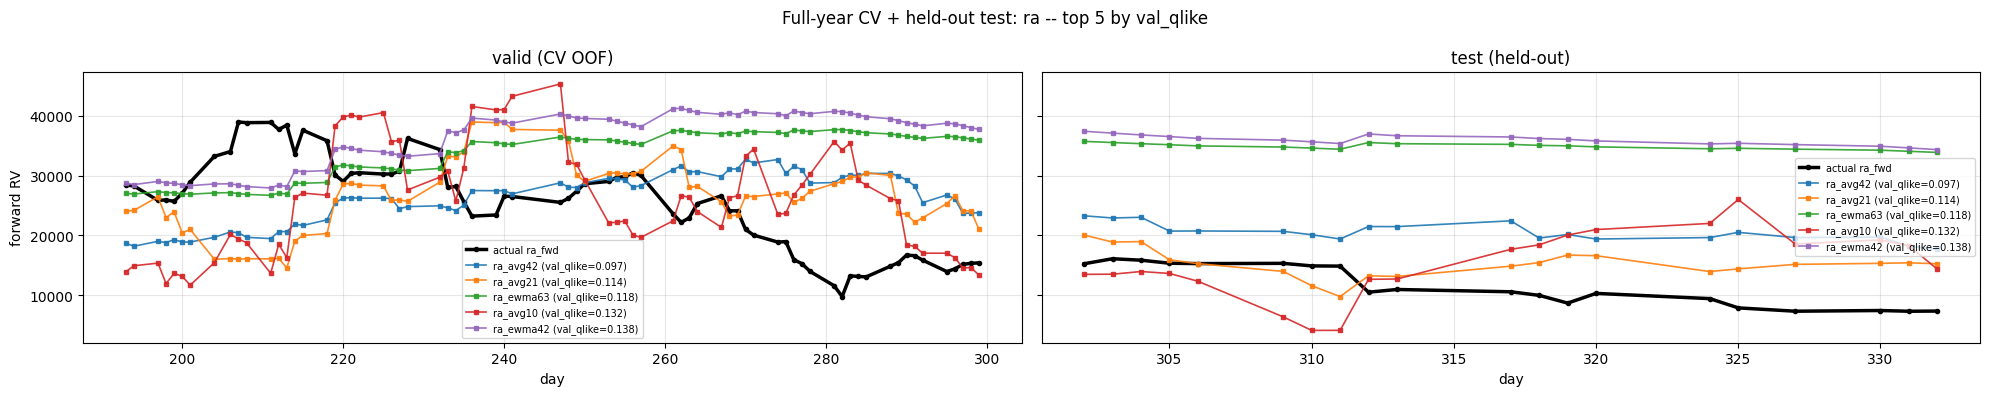


[rb] rb_ewma63
  features (1): rb_ewma63
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma63=1

[rb] rb_ewma42
  features (1): rb_ewma42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma42=1

[rb] rb_ewma21
  features (1): rb_ewma21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma21=1

[rb] rb_ewma10
  features (1): rb_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma10=1

[rb] rb_ewma5
  features (1): rb_ewma5
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma5=1


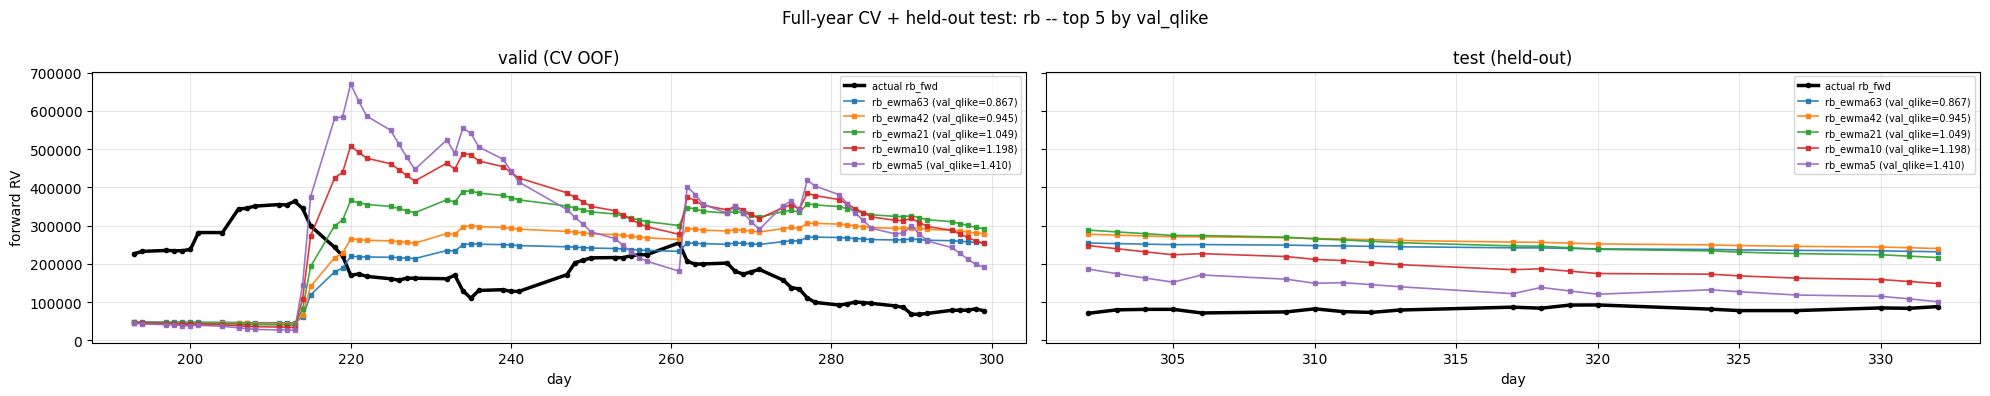


[rc] rc_ewma42
  features (1): rc_ewma42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_ewma42=1

[rc] rc_ewma63
  features (1): rc_ewma63
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_ewma63=1

[rc] ewma wHAR (Ridge scaled)
  best_params: ridge__alpha=1
  features (5): rc_ewma5, rc_ewma10, rc_ewma21, rc_ewma42, rc_ewma63
  intercept (target scale, original feature scale): -6364.76
  coefficients (all, 5): rc_ewma5=0.249656, rc_ewma10=-0.541387, rc_ewma21=-0.776944, rc_ewma42=0.542982, rc_ewma63=2.17513

[rc] rc_ewma21
  features (1): rc_ewma21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_ewma21=1

[rc] rc_ewma10
  features (1): rc_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_ewma10=1


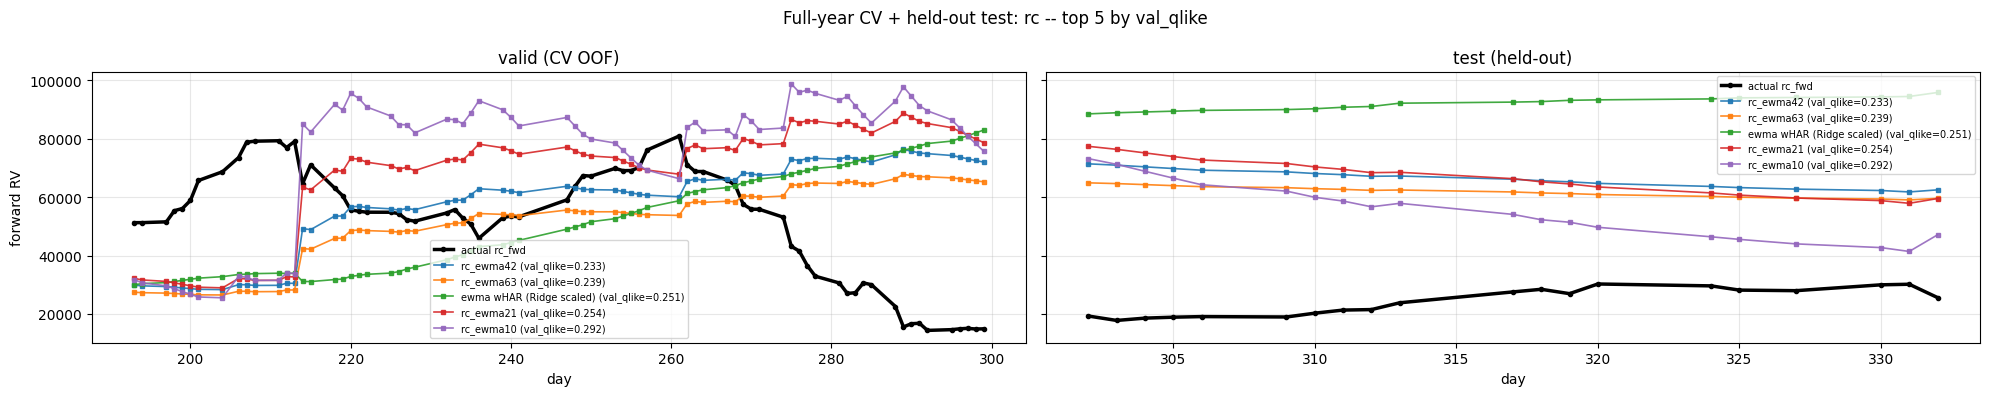


[rd] rd_ewma42
  features (1): rd_ewma42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_ewma42=1

[rd] rd_ewma63
  features (1): rd_ewma63
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_ewma63=1

[rd] rd_ewma21
  features (1): rd_ewma21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_ewma21=1

[rd] rd_ewma10
  features (1): rd_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_ewma10=1

[rd] rd_avg63
  features (1): rd_avg63
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_avg63=1


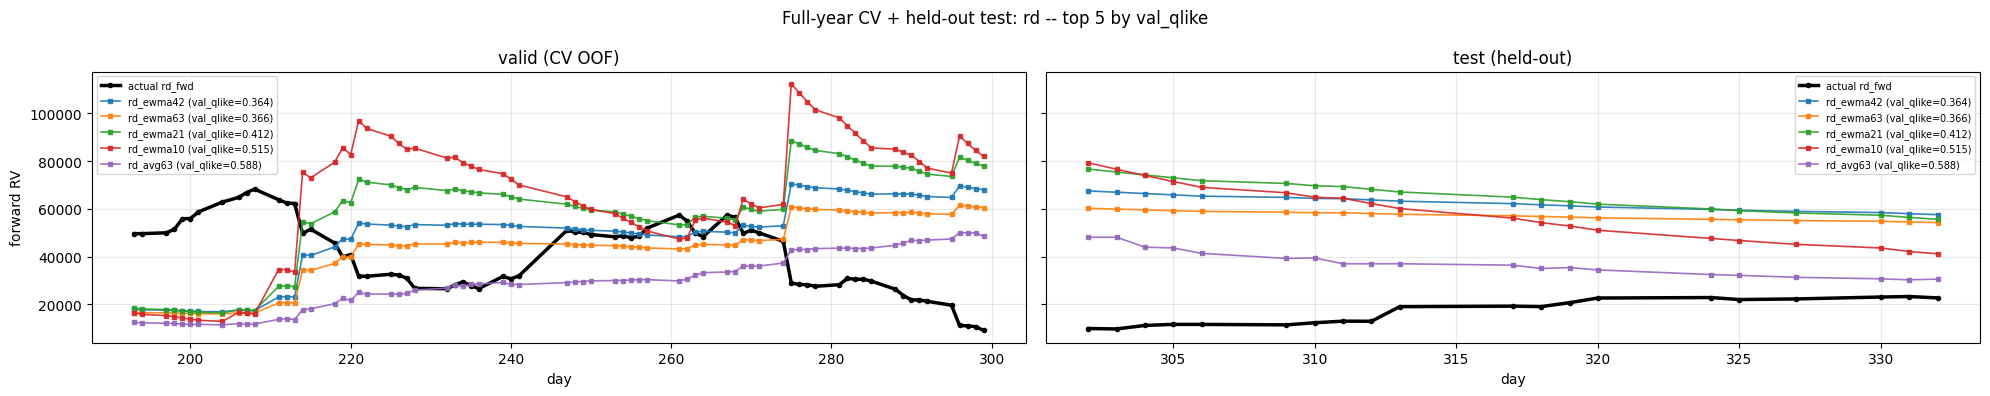


[re] re_avg63
  features (1): re_avg63
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): re_avg63=1

[re] HAR (Ridge scaled)
  best_params: ridge__alpha=10
  features (3): re, re_avg5, re_avg21
  intercept (target scale, original feature scale): 35270.2
  coefficients (all, 3): re=-0.0131104, re_avg5=-0.0608286, re_avg21=0.0496688

[re] HAR (LinReg)
  features (3): re, re_avg5, re_avg21
  intercept (target scale, original feature scale): 35126.8
  coefficients (all, 3): re=-0.013578, re_avg5=-0.068715, re_avg21=0.0613302

[re] log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (3): log_re, log_re_avg5, log_re_avg21
  intercept (log target scale, original feature scale): 11.0411
  coefficients (all, 3): log_re=-0.00825422, log_re_avg5=-0.0577511, log_re_avg21=0.0055717

[re] log HAR (LinReg)
  features (3): log_re, log_re_avg5, log_re_avg21
  intercept (log target scale, original feature scale): 11.0426
  coefficients (all, 3): 

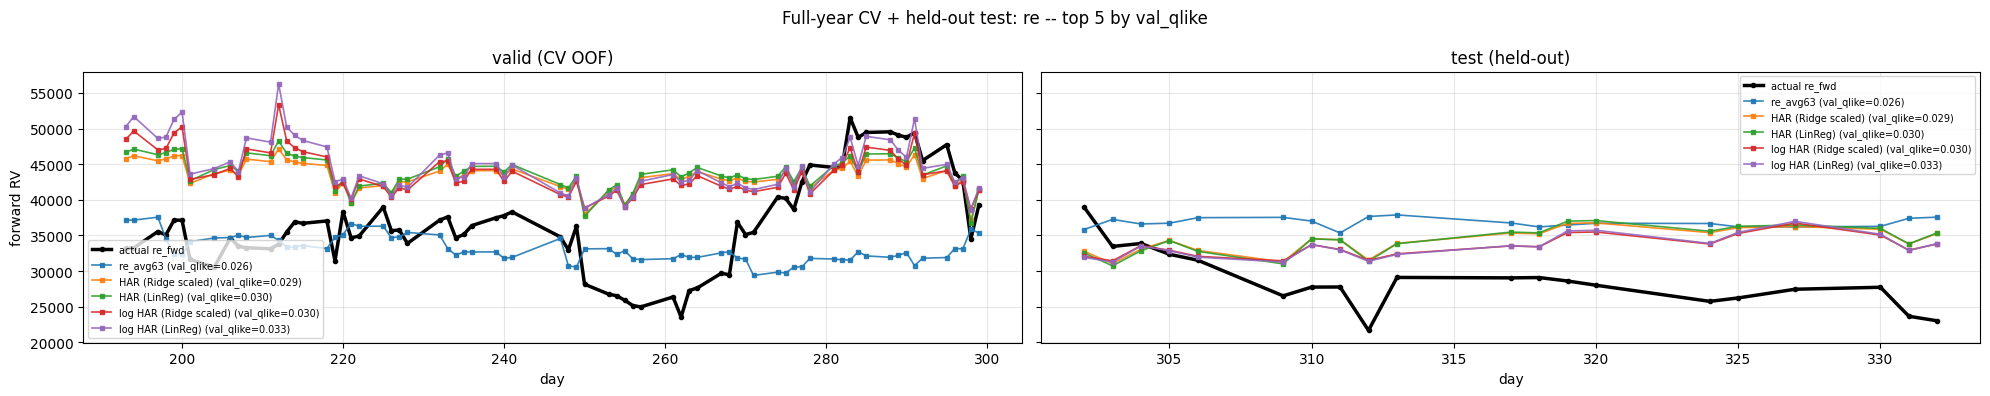


[rf] rf_ewma63
  features (1): rf_ewma63
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_ewma63=1

[rf] rf_ewma42
  features (1): rf_ewma42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_ewma42=1

[rf] rf_ewma21
  features (1): rf_ewma21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_ewma21=1

[rf] FS
  candidate features (66): ra, ra_avg10, ra_avg21, ra_avg42, ra_avg5, ra_avg63, ra_ewma10, ra_ewma21, ra_ewma42, ra_ewma5, ra_ewma63, rb, rb_avg10, rb_avg21, rb_avg42, rb_avg5, rb_avg63, rb_ewma10, rb_ewma21, rb_ewma42, rb_ewma5, rb_ewma63, rc, rc_avg10, rc_avg21, rc_avg42, rc_avg5, rc_avg63, rc_ewma10, rc_ewma21, rc_ewma42, rc_ewma5, rc_ewma63, rd, rd_avg10, rd_avg21, rd_avg42, rd_avg5, rd_avg63, rd_ewma10, rd_ewma21, rd_ewma42, rd_ewma5, rd_ewma63, re, re_avg10, re_avg21, re_avg42, re_avg5, re_avg63, re_ewma10, re_ewma21, re_ewma42, re_ewma5, re_ewma63, rf, rf_avg10, rf_a

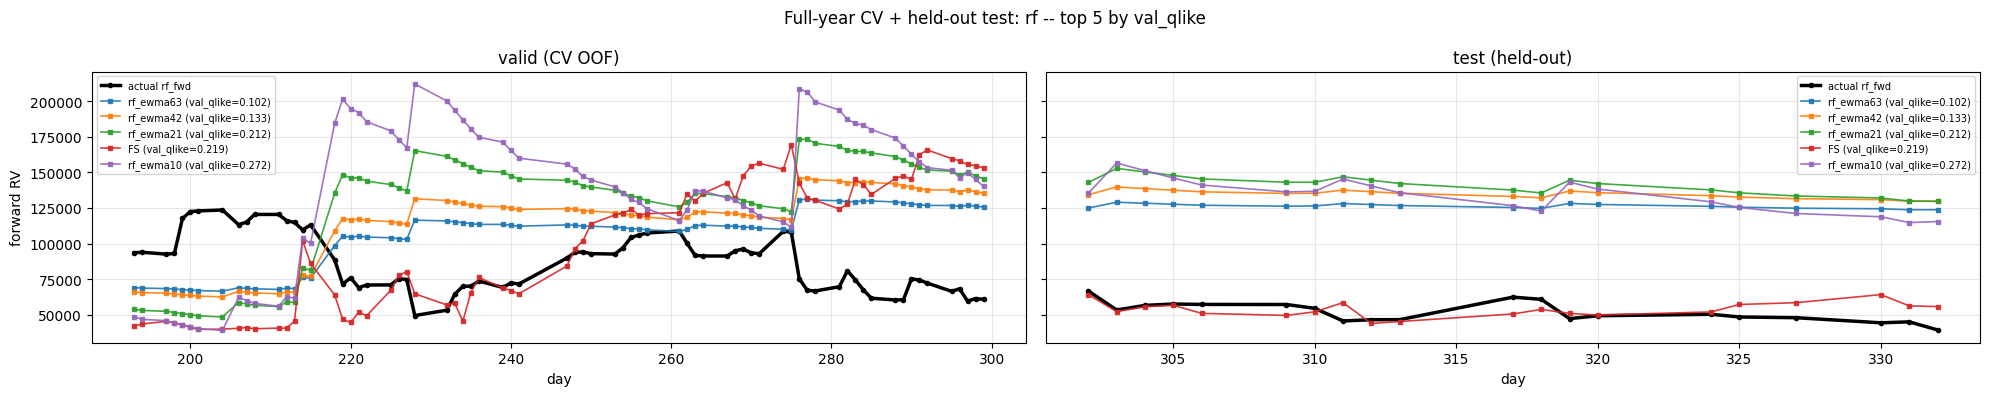

In [48]:
plot_top_models_last_fold(full_eval, top_k=5)


[ra] log HAR (LinReg)
  features (3): log_ra, log_ra_avg5, log_ra_avg21
  intercept (log target scale, original feature scale): 10.8196
  coefficients (all, 3): log_ra=-0.00750307, log_ra_avg5=-0.0706264, log_ra_avg21=0.0114998

[ra] log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=0.01
  features (3): log_ra, log_ra_avg5, log_ra_avg21
  intercept (log target scale, original feature scale): 10.8196
  coefficients (all, 3): log_ra=-0.007503, log_ra_avg5=-0.0706144, log_ra_avg21=0.0114879

[ra] HAR (Ridge scaled)
  best_params: ridge__alpha=0.01
  features (3): ra, ra_avg5, ra_avg21
  intercept (target scale, original feature scale): 28665.4
  coefficients (all, 3): ra=3.65006e-05, ra_avg5=-0.0751472, ra_avg21=-0.00253304


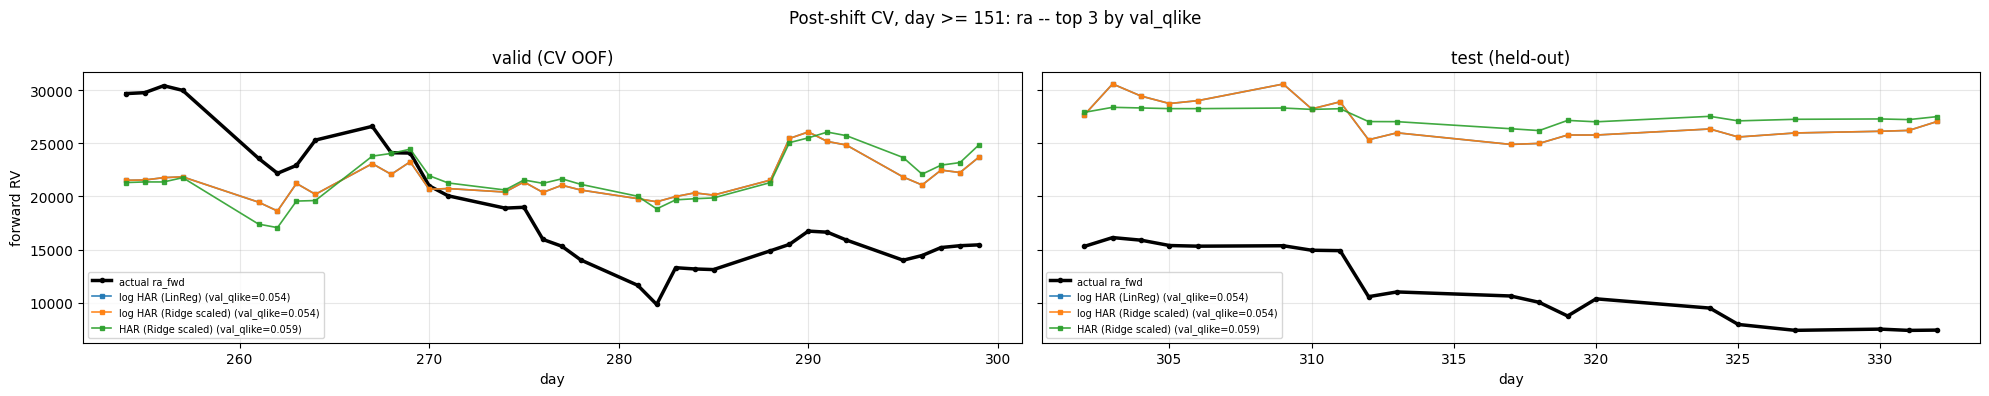


[rb] rb_avg42
  features (1): rb_avg42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_avg42=1

[rb] ewma log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (3): log_rb, log_rb_ewma5, log_rb_ewma21
  intercept (log target scale, original feature scale): 6.8203
  coefficients (all, 3): log_rb=0.0498552, log_rb_ewma5=-0.190134, log_rb_ewma21=0.552219

[rb] rb_avg21
  features (1): rb_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_avg21=1


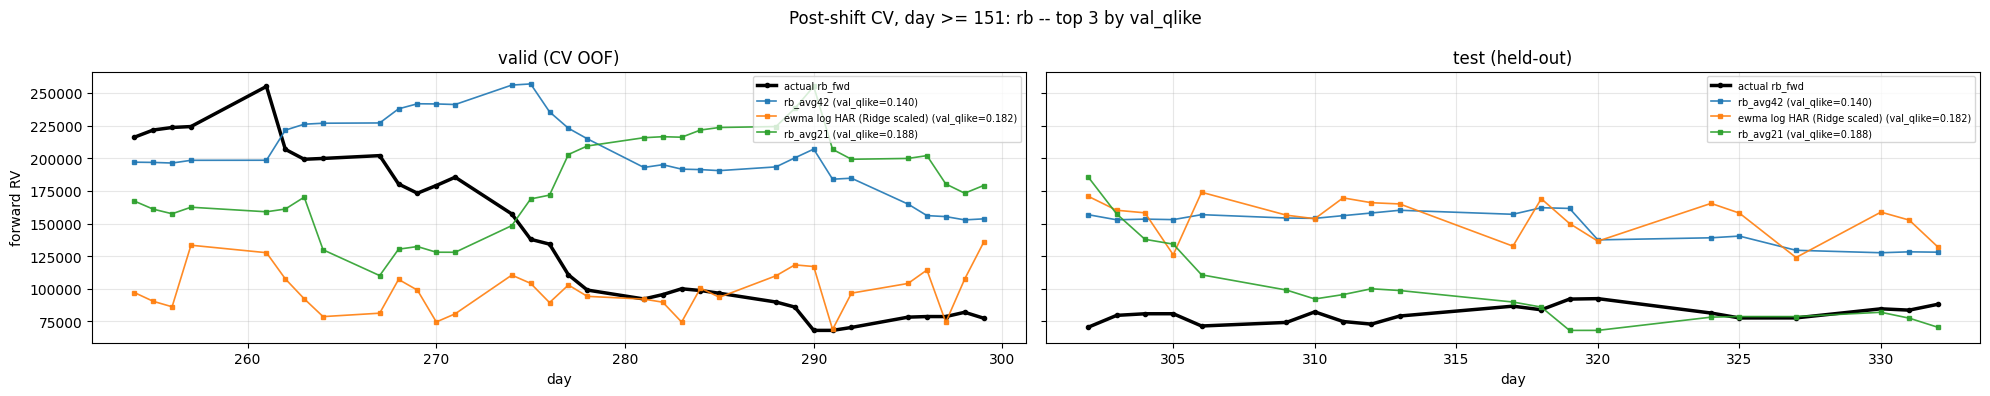


[rc] ewma HAR (Ridge scaled)
  best_params: ridge__alpha=10
  features (3): rc, rc_ewma5, rc_ewma21
  intercept (target scale, original feature scale): 25351.8
  coefficients (all, 3): rc=0.01417, rc_ewma5=-0.03698, rc_ewma21=0.490781

[rc] rc_avg42
  features (1): rc_avg42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_avg42=1

[rc] ewma log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (3): log_rc, log_rc_ewma5, log_rc_ewma21
  intercept (log target scale, original feature scale): 3.73585
  coefficients (all, 3): log_rc=0.000827393, log_rc_ewma5=-0.107255, log_rc_ewma21=0.75223


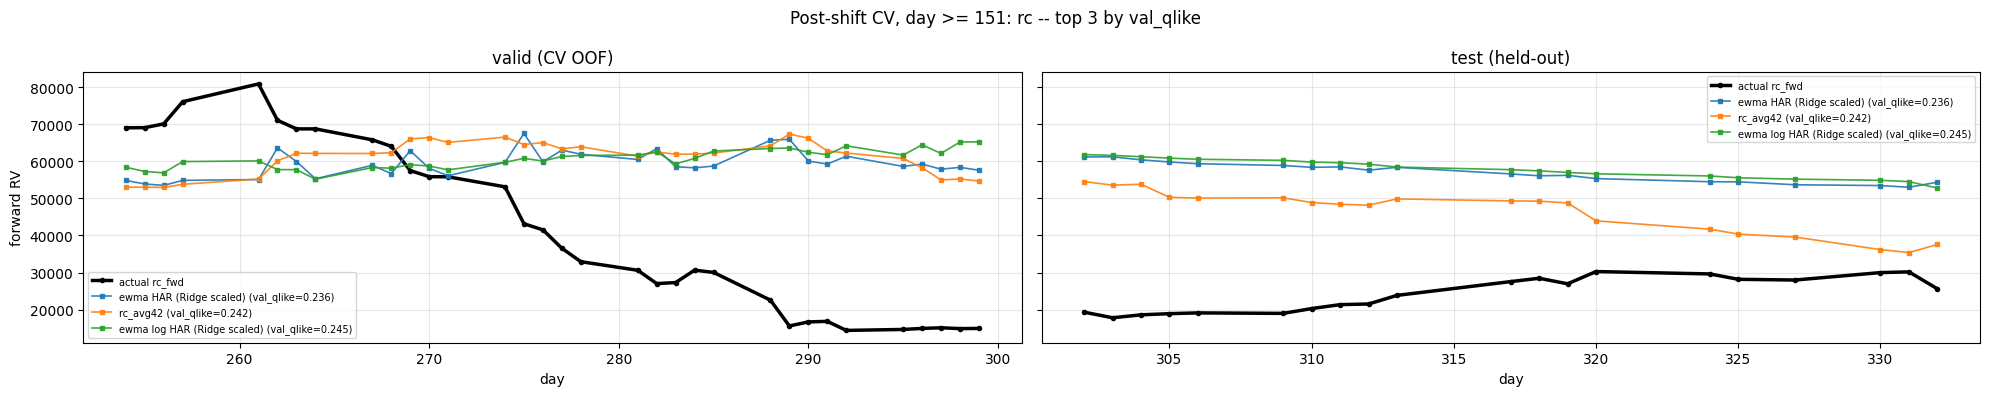


[rd] ewma log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=1
  features (3): log_rd, log_rd_ewma5, log_rd_ewma21
  intercept (log target scale, original feature scale): 3.75533
  coefficients (all, 3): log_rd=0.067995, log_rd_ewma5=-0.66511, log_rd_ewma21=1.22257

[rd] rd_avg42
  features (1): rd_avg42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_avg42=1

[rd] log FS
  candidate features (66): log_ra, log_ra_avg10, log_ra_avg21, log_ra_avg42, log_ra_avg5, log_ra_avg63, log_ra_ewma10, log_ra_ewma21, log_ra_ewma42, log_ra_ewma5, log_ra_ewma63, log_rb, log_rb_avg10, log_rb_avg21, log_rb_avg42, log_rb_avg5, log_rb_avg63, log_rb_ewma10, log_rb_ewma21, log_rb_ewma42, log_rb_ewma5, log_rb_ewma63, log_rc, log_rc_avg10, log_rc_avg21, log_rc_avg42, log_rc_avg5, log_rc_avg63, log_rc_ewma10, log_rc_ewma21, log_rc_ewma42, log_rc_ewma5, log_rc_ewma63, log_rd, log_rd_avg10, log_rd_avg21, log_rd_avg42, log_rd_avg5, log_rd_avg63, log_rd_ewma10, log

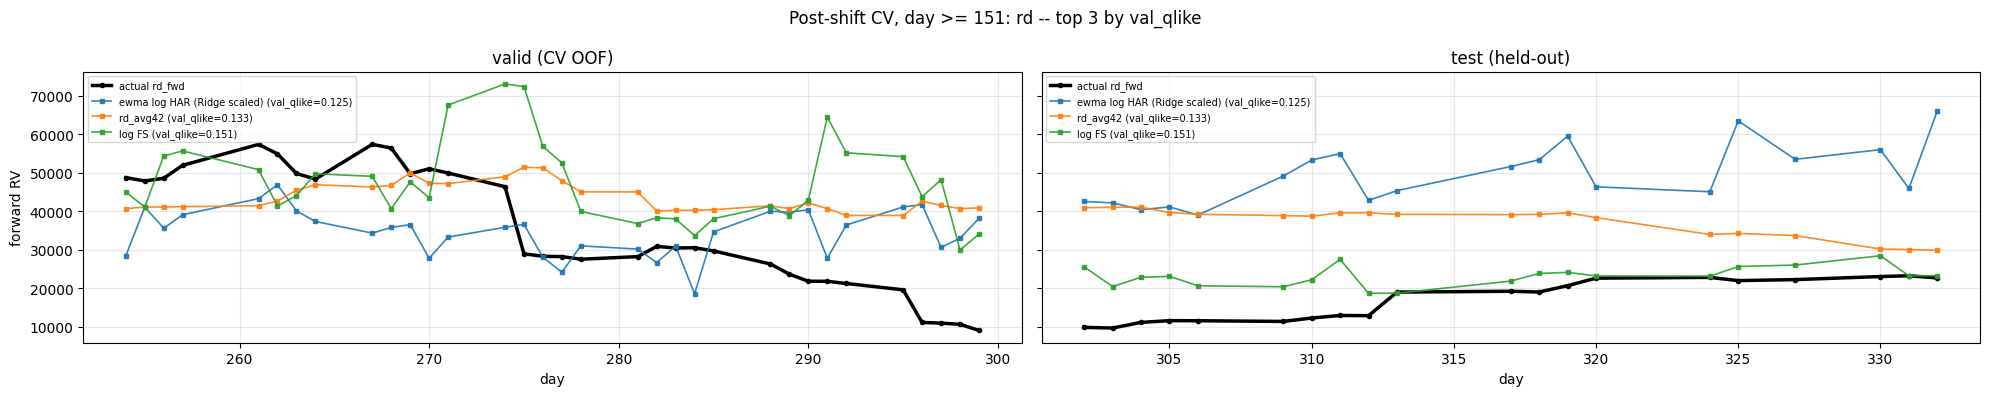


[re] FS
  candidate features (66): ra, ra_avg10, ra_avg21, ra_avg42, ra_avg5, ra_avg63, ra_ewma10, ra_ewma21, ra_ewma42, ra_ewma5, ra_ewma63, rb, rb_avg10, rb_avg21, rb_avg42, rb_avg5, rb_avg63, rb_ewma10, rb_ewma21, rb_ewma42, rb_ewma5, rb_ewma63, rc, rc_avg10, rc_avg21, rc_avg42, rc_avg5, rc_avg63, rc_ewma10, rc_ewma21, rc_ewma42, rc_ewma5, rc_ewma63, rd, rd_avg10, rd_avg21, rd_avg42, rd_avg5, rd_avg63, rd_ewma10, rd_ewma21, rd_ewma42, rd_ewma5, rd_ewma63, re, re_avg10, re_avg21, re_avg42, re_avg5, re_avg63, re_ewma10, re_ewma21, re_ewma42, re_ewma5, re_ewma63, rf, rf_avg10, rf_avg21, rf_avg42, rf_avg5, rf_avg63, rf_ewma10, rf_ewma21, rf_ewma42, rf_ewma5, rf_ewma63
  selected features (3): re_avg21, rd_avg21, ra_ewma10
  intercept (target scale, original feature scale): 50540.4
  coefficients (selected/nonzero, 3): re_avg21=-0.404056, rd_avg21=0.117317, ra_ewma10=-0.210505

[re] log FS
  candidate features (66): log_ra, log_ra_avg10, log_ra_avg21, log_ra_avg42, log_ra_avg5, log_ra_a

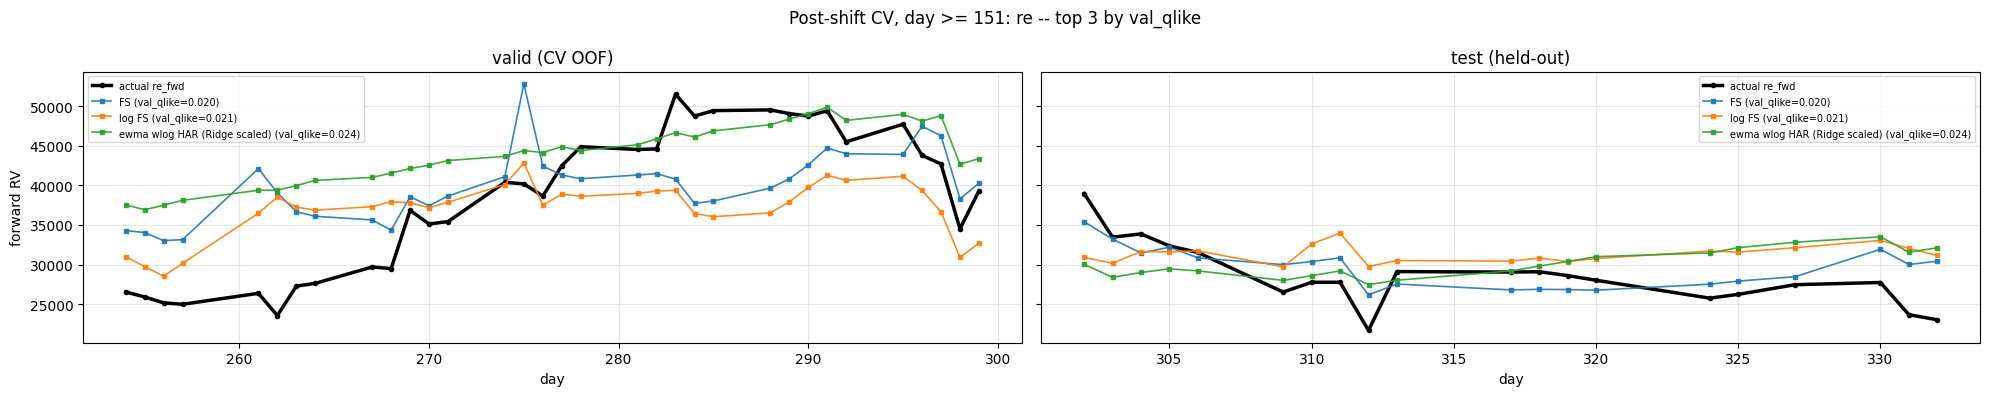


[rf] rf_avg42
  features (1): rf_avg42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_avg42=1

[rf] HAR (Ridge scaled)
  best_params: ridge__alpha=10
  features (3): rf, rf_avg5, rf_avg21
  intercept (target scale, original feature scale): 67403.2
  coefficients (all, 3): rf=0.00870292, rf_avg5=-0.00908431, rf_avg21=0.116291

[rf] HAR (LinReg)
  features (3): rf, rf_avg5, rf_avg21
  intercept (target scale, original feature scale): 66631.4
  coefficients (all, 3): rf=0.0108835, rf_avg5=-0.0183255, rf_avg21=0.138293


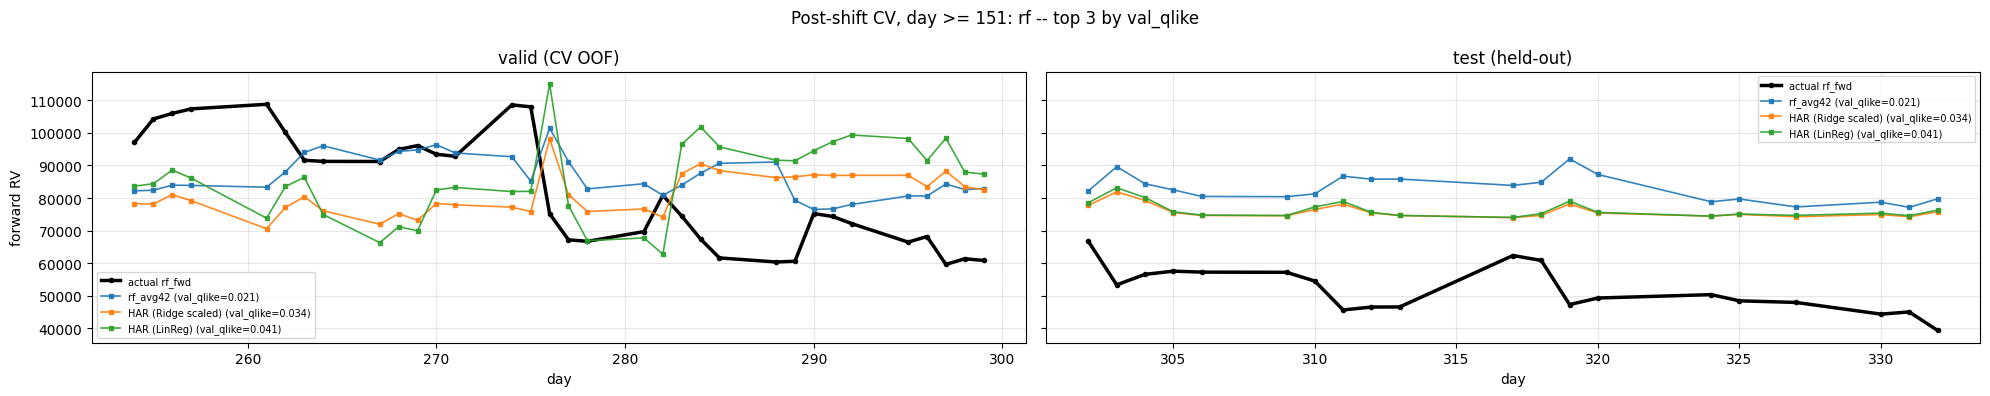

In [53]:
plot_top_models_last_fold(post_shift_eval, top_k=3)

In [50]:
def per_fold_breakdown(
    eval_result,
    top_k=3,
    ewma_windows=(1, 5, 11, 21),
    rank_metric="val_qlike",
    primary_loss="qlike",
    horizon=21,
):
    """Per stock: show pre-test CV fold losses and held-out test losses for
    the top-k tuned models plus EWMA pass-through baselines."""
    report = eval_result["report"]
    X_eval = eval_result["X"]
    cv = eval_result["cv"]
    label = eval_result["label"]
    model_results = eval_result.get("model_results", {})
    test_start_day = eval_result.get("test_start_day")
    test_end_day = eval_result.get("test_end_day")
    purge = eval_result.get("purge", horizon)
    train_span = eval_result.get("train_span")
    sort_std = f"{rank_metric}_std"
    sort_cols = [rank_metric] + ([sort_std] if sort_std in report.columns else [])

    print(label)
    for s in returns:
        spec_lookup = {
            name: (model, feats, grid)
            for name, model, feats, grid in model_specs_for_stock(s)
        }
        top = report.filter(pl.col("stock") == s).sort(sort_cols).head(top_k)
        rows = []
        target_col = f"{s}_fwd"

        # Top-k tuned models: read the stored pre-test CV folds and held-out
        # test metrics from run_model_report.
        for row in top.iter_rows(named=True):
            name = row["model"]
            if name not in spec_lookup:
                continue
            model, feats, grid = spec_lookup[name]
            r = model_results.get((s, name))
            if r is None:
                r = evaluate_model_with_test(
                    X_eval,
                    y,
                    model,
                    feats,
                    target_col,
                    param_grid=grid,
                    cv=cv,
                    horizon=horizon,
                    primary_loss=primary_loss,
                    test_start_day=test_start_day,
                    test_end_day=test_end_day,
                    purge=purge,
                    train_span=train_span,
                )
            qfolds = np.asarray(r["qlike_fold_errors"], dtype=float)
            rfolds = np.asarray(r["rmse_fold_errors"], dtype=float)
            rows.append(
                {
                    "kind": "top",
                    "model": name,
                    "qlike_folds": [round(float(v), 4) for v in qfolds],
                    "cv_qlike_mean": round(float(qfolds.mean()), 4),
                    "cv_qlike_std": round(float(qfolds.std()), 4),
                    "rmse_folds": [round(float(v), 2) for v in rfolds],
                    "cv_rmse_mean": round(float(rfolds.mean()), 2),
                    "cv_rmse_std": round(float(rfolds.std()), 2),
                    "test_qlike": round(float(r.get("test_qlike", np.nan)), 4),
                    "test_rmse": round(float(r.get("test_rmse", np.nan)), 2),
                }
            )

        # EWMA pass-through baselines: prediction = feature at t, no fit.
        for w in ewma_windows:
            feat = f"{s}_ewma{w}"
            if feat not in X_eval.columns:
                continue
            baseline_name = f"EWMA-{w} (pass)"
            r = model_results.get((s, baseline_name))
            if r is None:
                r = evaluate_model_with_test(
                    X_eval,
                    y,
                    PassthroughRegressor(),
                    [feat],
                    target_col,
                    cv=cv,
                    horizon=horizon,
                    primary_loss=primary_loss,
                    test_start_day=test_start_day,
                    test_end_day=test_end_day,
                    purge=purge,
                    train_span=train_span,
                )
            qfolds = np.asarray(r["qlike_fold_errors"], dtype=float)
            rfolds = np.asarray(r["rmse_fold_errors"], dtype=float)
            rows.append(
                {
                    "kind": "ewma",
                    "model": baseline_name,
                    "qlike_folds": [round(float(v), 4) for v in qfolds],
                    "cv_qlike_mean": round(float(qfolds.mean()), 4),
                    "cv_qlike_std": round(float(qfolds.std()), 4),
                    "rmse_folds": [round(float(v), 2) for v in rfolds],
                    "cv_rmse_mean": round(float(rfolds.mean()), 2),
                    "cv_rmse_std": round(float(rfolds.std()), 2),
                    "test_qlike": round(float(r.get("test_qlike", np.nan)), 4),
                    "test_rmse": round(float(r.get("test_rmse", np.nan)), 2),
                }
            )

        if not rows:
            continue
        out = pl.DataFrame(rows)
        print(f"\n--- target: {target_col} ---")
        with pl.Config(tbl_cols=12, tbl_rows=20, fmt_str_lengths=160):
            display(out)

In [51]:
per_fold_breakdown(full_eval, top_k=3, ewma_windows=tuple(windows))

Full-year CV + held-out test

--- target: ra_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""ra_avg42""",[0.0974],0.0974,0.0,[10675.76],10675.76,0.0,0.173,9368.87
"""top""","""ra_avg21""",[0.1139],0.1139,0.0,[11097.39],11097.39,0.0,0.0849,5271.09
"""top""","""ra_ewma63""",[0.1178],0.1178,0.0,[13862.39],13862.39,0.0,0.4756,23451.56
"""ewma""","""EWMA-1 (pass)""",[0.2418],0.2418,0.0,[24805.51],24805.51,0.0,0.4557,19090.45
"""ewma""","""EWMA-5 (pass)""",[0.1701],0.1701,0.0,[20719.68],20719.68,0.0,0.3019,15911.69
"""ewma""","""EWMA-10 (pass)""",[0.1766],0.1766,0.0,[20299.27],20299.27,0.0,0.3684,18308.86
"""ewma""","""EWMA-21 (pass)""",[0.1665],0.1665,0.0,[18845.86],18845.86,0.0,0.4686,23143.5
"""ewma""","""EWMA-42 (pass)""",[0.1378],0.1378,0.0,[15899.11],15899.11,0.0,0.4957,24507.86
"""ewma""","""EWMA-63 (pass)""",[0.1178],0.1178,0.0,[13862.39],13862.39,0.0,0.4756,23451.56



--- target: rb_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rb_ewma63""",[0.8669],0.8669,0.0,[156347.01],156347.01,0.0,0.4372,162847.75
"""top""","""rb_ewma42""",[0.945],0.945,0.0,[174973.85],174973.85,0.0,0.4798,178897.85
"""top""","""rb_ewma21""",[1.0495],1.0495,0.0,[208753.92],208753.92,0.0,0.4601,172926.82
"""ewma""","""EWMA-1 (pass)""",[2.3688],2.3688,0.0,[286919.5],286919.5,0.0,0.0995,48323.52
"""ewma""","""EWMA-5 (pass)""",[1.41],1.41,0.0,[253544.94],253544.94,0.0,0.1372,65302.39
"""ewma""","""EWMA-10 (pass)""",[1.1976],1.1976,0.0,[235743.8],235743.8,0.0,0.2994,119079.72
"""ewma""","""EWMA-21 (pass)""",[1.0495],1.0495,0.0,[208753.92],208753.92,0.0,0.4601,172926.82
"""ewma""","""EWMA-42 (pass)""",[0.945],0.945,0.0,[174973.85],174973.85,0.0,0.4798,178897.85
"""ewma""","""EWMA-63 (pass)""",[0.8669],0.8669,0.0,[156347.01],156347.01,0.0,0.4372,162847.75



--- target: rc_fwd ---


...

kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rd_ewma42""",[0.3642],0.3642,0.0,[31410.82],31410.82,0.0,0.6277,46214.31
"""top""","""rd_ewma63""",[0.3662],0.3662,0.0,[28023.74],28023.74,0.0,0.5641,40826.69
"""top""","""rd_ewma21""",[0.4119],0.4119,0.0,[38960.68],38960.68,0.0,0.6674,50145.99
"""ewma""","""EWMA-1 (pass)""",[1.4046],1.4046,0.0,[61015.17],61015.17,0.0,0.2534,13690.09
"""ewma""","""EWMA-5 (pass)""",[0.6524],0.6524,0.0,[53205.38],53205.38,0.0,0.4183,33690.11
"""ewma""","""EWMA-10 (pass)""",[0.5148],0.5148,0.0,[47015.3],47015.3,0.0,0.5857,44705.74
"""ewma""","""EWMA-21 (pass)""",[0.4119],0.4119,0.0,[38960.68],38960.68,0.0,0.6674,50145.99
"""ewma""","""EWMA-42 (pass)""",[0.3642],0.3642,0.0,[31410.82],31410.82,0.0,0.6277,46214.31
"""ewma""","""EWMA-63 (pass)""",[0.3662],0.3662,0.0,[28023.74],28023.74,0.0,0.5641,40826.69



--- target: re_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""re_avg63""",[0.026],0.026,0.0,[8055.01],8055.01,0.0,0.0392,9217.75
"""top""","""HAR (Ridge scaled)""",[0.0287],0.0287,0.0,[9247.5],9247.5,0.0,0.0271,7382.47
"""top""","""HAR (LinReg)""",[0.0305],0.0305,0.0,[9627.28],9627.28,0.0,0.0277,7475.51
"""ewma""","""EWMA-1 (pass)""",[0.2038],0.2038,0.0,[28544.81],28544.81,0.0,0.2367,40449.41
"""ewma""","""EWMA-5 (pass)""",[0.0748],0.0748,0.0,[18699.52],18699.52,0.0,0.2713,38895.44
"""ewma""","""EWMA-10 (pass)""",[0.0777],0.0777,0.0,[18141.27],18141.27,0.0,0.2572,35638.7
"""ewma""","""EWMA-21 (pass)""",[0.1073],0.1073,0.0,[22568.23],22568.23,0.0,0.2279,31869.43
"""ewma""","""EWMA-42 (pass)""",[0.1335],0.1335,0.0,[26332.58],26332.58,0.0,0.2277,31761.24
"""ewma""","""EWMA-63 (pass)""",[0.1272],0.1272,0.0,[25292.36],25292.36,0.0,0.2247,31403.78



--- target: rf_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rf_ewma63""",[0.1016],0.1016,0.0,[43022.87],43022.87,0.0,0.3098,74782.66
"""top""","""rf_ewma42""",[0.1329],0.1329,0.0,[51929.39],51929.39,0.0,0.3479,83054.15
"""top""","""rf_ewma21""",[0.2119],0.2119,0.0,[69042.11],69042.11,0.0,0.3754,89337.02
"""ewma""","""EWMA-1 (pass)""",[0.6576],0.6576,0.0,[116167.08],116167.08,0.0,0.2339,80363.46
"""ewma""","""EWMA-5 (pass)""",[0.3067],0.3067,0.0,[96237.64],96237.64,0.0,0.2917,73516.34
"""ewma""","""EWMA-10 (pass)""",[0.2724],0.2724,0.0,[84827.08],84827.08,0.0,0.3433,83002.49
"""ewma""","""EWMA-21 (pass)""",[0.2119],0.2119,0.0,[69042.11],69042.11,0.0,0.3754,89337.02
"""ewma""","""EWMA-42 (pass)""",[0.1329],0.1329,0.0,[51929.39],51929.39,0.0,0.3479,83054.15
"""ewma""","""EWMA-63 (pass)""",[0.1016],0.1016,0.0,[43022.87],43022.87,0.0,0.3098,74782.66


In [52]:
per_fold_breakdown(post_shift_eval, top_k=3, ewma_windows=tuple(windows))

Post-shift CV, day >= 151

--- target: ra_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""log HAR (LinReg)""",[0.0541],0.0541,0.0,[6569.74],6569.74,0.0,0.3155,15751.84
"""top""","""log HAR (Ridge scaled)""",[0.0541],0.0541,0.0,[6569.9],6569.9,0.0,0.3155,15751.76
"""top""","""HAR (Ridge scaled)""",[0.0592],0.0592,0.0,[6924.01],6924.01,0.0,0.3279,16236.4
"""ewma""","""EWMA-1 (pass)""",[0.2391],0.2391,0.0,[20307.07],20307.07,0.0,0.4557,19090.45
"""ewma""","""EWMA-5 (pass)""",[0.2414],0.2414,0.0,[21490.38],21490.38,0.0,0.3019,15911.69
"""ewma""","""EWMA-10 (pass)""",[0.2868],0.2868,0.0,[24072.98],24072.98,0.0,0.3684,18308.86
"""ewma""","""EWMA-21 (pass)""",[0.2976],0.2976,0.0,[24441.58],24441.58,0.0,0.4686,23143.5
"""ewma""","""EWMA-42 (pass)""",[0.2591],0.2591,0.0,[21470.82],21470.82,0.0,0.4957,24507.86
"""ewma""","""EWMA-63 (pass)""",[0.2229],0.2229,0.0,[18811.79],18811.79,0.0,0.4756,23451.56



--- target: rb_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rb_avg42""",[0.1399],0.1399,0.0,[83195.45],83195.45,0.0,0.1564,69139.9
"""top""","""ewma log HAR (Ridge scaled)""",[0.1825],0.1825,0.0,[72699.89],72699.89,0.0,0.1747,75572.0
"""top""","""rb_avg21""",[0.1884],0.1884,0.0,[98187.8],98187.8,0.0,0.0558,39134.24
"""ewma""","""EWMA-1 (pass)""",[0.5691],0.5691,0.0,[205494.71],205494.71,0.0,0.0995,48323.52
"""ewma""","""EWMA-5 (pass)""",[0.3268],0.3268,0.0,[183685.53],183685.53,0.0,0.1372,65302.39
"""ewma""","""EWMA-10 (pass)""",[0.3662],0.3662,0.0,[196714.72],196714.72,0.0,0.2994,119079.72
"""ewma""","""EWMA-21 (pass)""",[0.373],0.373,0.0,[197513.96],197513.96,0.0,0.4601,172926.82
"""ewma""","""EWMA-42 (pass)""",[0.3103],0.3103,0.0,[163693.51],163693.51,0.0,0.4798,178897.85
"""ewma""","""EWMA-63 (pass)""",[0.2554],0.2554,0.0,[135633.73],135633.73,0.0,0.4372,162847.75



--- target: rc_fwd ---


...

kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""ewma log HAR (Ridge scaled)""",[0.1249],0.1249,0.0,[15353.72],15353.72,0.0,0.4508,33169.9
"""top""","""rd_avg42""",[0.1327],0.1327,0.0,[16649.86],16649.86,0.0,0.3033,21938.99
"""top""","""log FS""",[0.1505],0.1505,0.0,[20577.69],20577.69,0.0,0.0877,7867.54
"""ewma""","""EWMA-1 (pass)""",[0.607],0.607,0.0,[67977.1],67977.1,0.0,0.2534,13690.09
"""ewma""","""EWMA-5 (pass)""",[0.4303],0.4303,0.0,[57721.76],57721.76,0.0,0.4183,33690.11
"""ewma""","""EWMA-10 (pass)""",[0.3957],0.3957,0.0,[51645.69],51645.69,0.0,0.5857,44705.74
"""ewma""","""EWMA-21 (pass)""",[0.3484],0.3484,0.0,[43878.98],43878.98,0.0,0.6674,50145.99
"""ewma""","""EWMA-42 (pass)""",[0.2799],0.2799,0.0,[34351.34],34351.34,0.0,0.6277,46214.31
"""ewma""","""EWMA-63 (pass)""",[0.237],0.237,0.0,[28589.25],28589.25,0.0,0.5641,40826.69



--- target: re_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""FS""",[0.0204],0.0204,0.0,[7477.56],7477.56,0.0,0.0064,3197.04
"""top""","""log FS""",[0.0213],0.0213,0.0,[7675.87],7675.87,0.0,0.0138,4932.11
"""top""","""ewma wlog HAR (Ridge scaled)""",[0.0237],0.0237,0.0,[7768.94],7768.94,0.0,0.0133,4848.71
"""ewma""","""EWMA-1 (pass)""",[0.1633],0.1633,0.0,[27484.39],27484.39,0.0,0.2367,40449.41
"""ewma""","""EWMA-5 (pass)""",[0.094],0.094,0.0,[20728.28],20728.28,0.0,0.2713,38895.44
"""ewma""","""EWMA-10 (pass)""",[0.0822],0.0822,0.0,[18418.45],18418.45,0.0,0.2572,35638.7
"""ewma""","""EWMA-21 (pass)""",[0.0866],0.0866,0.0,[18977.27],18977.27,0.0,0.2279,31869.43
"""ewma""","""EWMA-42 (pass)""",[0.1085],0.1085,0.0,[22368.54],22368.54,0.0,0.2277,31761.24
"""ewma""","""EWMA-63 (pass)""",[0.1094],0.1094,0.0,[22454.25],22454.25,0.0,0.2247,31403.78



--- target: rf_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rf_avg42""",[0.0214],0.0214,0.0,[17131.77],17131.77,0.0,0.1037,32048.1
"""top""","""HAR (Ridge scaled)""",[0.0345],0.0345,0.0,[21464.97],21464.97,0.0,0.0733,25132.45
"""top""","""HAR (LinReg)""",[0.0413],0.0413,0.0,[24322.13],24322.13,0.0,0.0751,25559.35
"""ewma""","""EWMA-1 (pass)""",[0.317],0.317,0.0,[110315.67],110315.67,0.0,0.2339,80363.46
"""ewma""","""EWMA-5 (pass)""",[0.1935],0.1935,0.0,[87941.77],87941.77,0.0,0.2917,73516.34
"""ewma""","""EWMA-10 (pass)""",[0.1914],0.1914,0.0,[80676.98],80676.98,0.0,0.3433,83002.49
"""ewma""","""EWMA-21 (pass)""",[0.1706],0.1706,0.0,[71185.67],71185.67,0.0,0.3754,89337.02
"""ewma""","""EWMA-42 (pass)""",[0.1262],0.1262,0.0,[55979.66],55979.66,0.0,0.3479,83054.15
"""ewma""","""EWMA-63 (pass)""",[0.0968],0.0968,0.0,[45919.01],45919.01,0.0,0.3098,74782.66
